# Project Exploratory Data Analysis

## Project Overview
**Goal**: Predict `ADHD_Outcome` (0/1) and `Sex_F` (0/1) using fMRI connectivity, demographics, and behavioral data.
**Data Source**: Kaggle WiDS Datathon 2025

## Notebook Structure:
1. **Setup**: Library imports and visualization style.
2. **Data Loading (Cleaned)**: Loading the pre-processed/cleaned dataset.
3. **Missing Value Analysis (Raw)**: Analyzing initial data quality.
4. **Target Analysis**: Distribution of ADHD and Sex.
5. **Feature EDA**: Demographics, Quantitative features.
6. **Functional Connectivity**: fMRI analysis.

## 1. Imports & Visualization Setup
Setting up the environment and loading libraries.

In [1]:
import os
import sys

# ------------------------------------------------------------------------------
# Setup for Colab (Install dependencies first)
# ------------------------------------------------------------------------------
if 'google.colab' in sys.modules:
    print("Detected Google Colab environment.")
    print("Installing missingno...")
    !pip install -q missingno

    print("Mounting Google Drive to access font file...")
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

# Preprocessing & Analysis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional: Missing values visualization
try:
    import missingno as msno
except ImportError:
    # If import fails, try installing it again (fallback) and re-importing
    if 'google.colab' in sys.modules:
        print("Import failed. Trying to force install missingno again...")
        !pip install missingno
        import missingno as msno
    else:
        print("missingno not found, skipping specific plots.")

# ------------------------------------------------------------------------------
# Visualization Style Settings
# ------------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
# Use a gradient-friendly palette as default for numeric plots if needed
PALETTE = "viridis"
sns.set_palette(PALETTE)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# ------------------------------------------------------------------------------
# STRICT FONT CONFIGURATION: FORCE TIMES NEW ROMAN
# ------------------------------------------------------------------------------
import matplotlib.font_manager as fm
import urllib.request

def configure_times_new_roman():
    # 1. Check if Times New Roman is already available in system fonts
    # Use lowercase comparison for robustness
    font_names = [f.name.lower() for f in fm.fontManager.ttflist]
    if 'times new roman' in font_names:
        # Update rcParams globally
        plt.rcParams.update({
            'font.family': 'serif',
            'font.serif': ['Times New Roman'] + plt.rcParams['font.serif'],
            # Force axes and tick labels to use the font
            'axes.labelweight': 'normal',
            'axes.titleweight': 'normal',
            'font.weight': 'normal'
        })
        # Override seaborn's internal font management
        sns.set_theme(style="whitegrid", rc={"font.family": "serif", "font.serif": ["Times New Roman"]})

        print("Success: 'Times New Roman' found in system fonts and set.")
        return

    print("Warning: 'Times New Roman' not found in system fonts.")

    # 2. Look for user-provided font file locally or in Drive
    possible_font_paths = [
        "Times New Roman.TTF", # Current directory
        "Times New Roman.ttf",
        "Times_New_Roman.ttf",
        "/content/drive/MyDrive/Times New Roman.TTF",
        "/content/drive/MyDrive/Times New Roman.ttf",
        "/content/Times New Roman.TTF",
        "/content/Times New Roman.ttf"
    ]

    font_path = None
    for p in possible_font_paths:
        if os.path.exists(p):
            font_path = p
            print(f"Found local font file at: {p}")
            break

    # 3. If not found locally, try to download (Fallback)
    if not font_path:
        print("Font file not found locally. Attempting download...")
        font_urls = [
            "https://github.com/dbhu/Times-New-Roman/raw/master/times.ttf",
            "https://github.com/mrbje/Scientific-Fonts/raw/master/Times-New-Roman.ttf",
            "https://github.com/ultralytics/yolov5/releases/download/v1.0/Times.New.Roman.ttf"
        ]
        target_path = "Times_New_Roman.ttf"

        for url in font_urls:
            try:
                print(f"Downloading from {url}...")
                req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req) as response, open(target_path, 'wb') as out_file:
                    out_file.write(response.read())
                if os.path.getsize(target_path) > 1000:
                    font_path = target_path
                    print("Download successful.")
                    break
            except Exception as e:
                print(f"Download failed: {e}")

    # 4. Load and Configure
    if font_path and os.path.exists(font_path):
        try:
            # Use FontEntry for direct addition to manager
            fe = fm.FontEntry(
                fname=font_path,
                name='Times New Roman'
            )
            fm.fontManager.ttflist.insert(0, fe) # Priority 1

            # Update rcParams globally
            plt.rcParams.update({
                'font.family': 'serif',
                'font.serif': ['Times New Roman'] + plt.rcParams['font.serif'],
            })
            # Override seaborn's internal font management
            sns.set_theme(style="whitegrid", rc={"font.family": "serif", "font.serif": ["Times New Roman"]})

            print(f"Success: Loaded 'Times New Roman' from {font_path} and set as primary.")
        except Exception as e:
            print(f"Failed to load font file: {e}")
            raise RuntimeError("CRITICAL: Failed to load Times New Roman font. Stopping execution.")
    else:
        print("CRITICAL: Times New Roman font not found anywhere.")
        raise RuntimeError("CRITICAL: Times New Roman font not found. Please upload the font file or install it. Stopping execution to ensure correct formatting.")

configure_times_new_roman()

# Custom Color Palette
COLOR_HEALTHY = '#6BAED6' # Light Blue (Healthy Control)
COLOR_ADHD = '#542788'    # Dark Purple (ADHD)
COLOR_MALE = '#006400'    # Dark Green (Male)
COLOR_FEMALE = '#FFB6C1'  # Light Pink (Female)

PALETTE_ADHD = [COLOR_HEALTHY, COLOR_ADHD]
PALETTE_SEX = [COLOR_MALE, COLOR_FEMALE]

# Global Colormap for Gradients (Academic standard)
GLOBAL_CMAP = "viridis"
# Or "coolwarm" for diverging data (negative to positive)
GLOBAL_DIVERGING_CMAP = "coolwarm"

print("Libraries imported and style set.")
!pip -q install nilearn


Detected Google Colab environment.
Installing missingno...
Mounting Google Drive to access font file...
Mounted at /content/drive
Found local font file at: /content/drive/MyDrive/Times New Roman.TTF
Success: Loaded 'Times New Roman' from /content/drive/MyDrive/Times New Roman.TTF and set as primary.
Libraries imported and style set.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 75.6 MB/s eta 0:00:00


## 2. Data Loading: Cleaned Data
Loading the pre-processed dataset for analysis.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Cleaned Data for EDA...
Searching in Train directory: /content/drive/MyDrive/cleaned_data/cleaned_data
Found Training Solutions in Raw Dir: /content/drive/MyDrive/widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx
Found 4 files to merge.
Reading: cleaned_train_categorical.csv ... Shape: (1208, 21)
Reading: cleaned_train_quantitative.csv ... Shape: (1208, 37)
Reading: cleaned_train_connectome.csv ... Shape: (1208, 19901)
  -> Renamed 2080 connectome columns
Reading: TRAINING_SOLUTIONS.xlsx ... Shape: (1213, 3)
Cleaned Data Loaded. Final Shape: (1208, 19959)
DEBUG: Sex columns found: ['Sex_F_x', 'Sex_F__missing_ind', 'Sex_F_y']
Renaming 'Sex_F_y' to 'Sex_F'...
Columns (first 10): ['participant_id', 'Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_B

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,21.0,45.0,...,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032,1,0
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,...,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978,1,0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,21.0,45.0,...,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182,0,1



--- Dataset Integrity Check (Cleaned Data) ---
Core Subset Shape: (1208, 36)
Duplicate Rows: 0

Missing Values in Core Variables:


,Missing Count,Missing Ratio



Data Types Overview:


,count
int64,18
float64,17
object,1


Summary: 35 numeric features (97.2%) and 1 categorical/object features.
Memory Usage for Core Variables: 0.39 MB


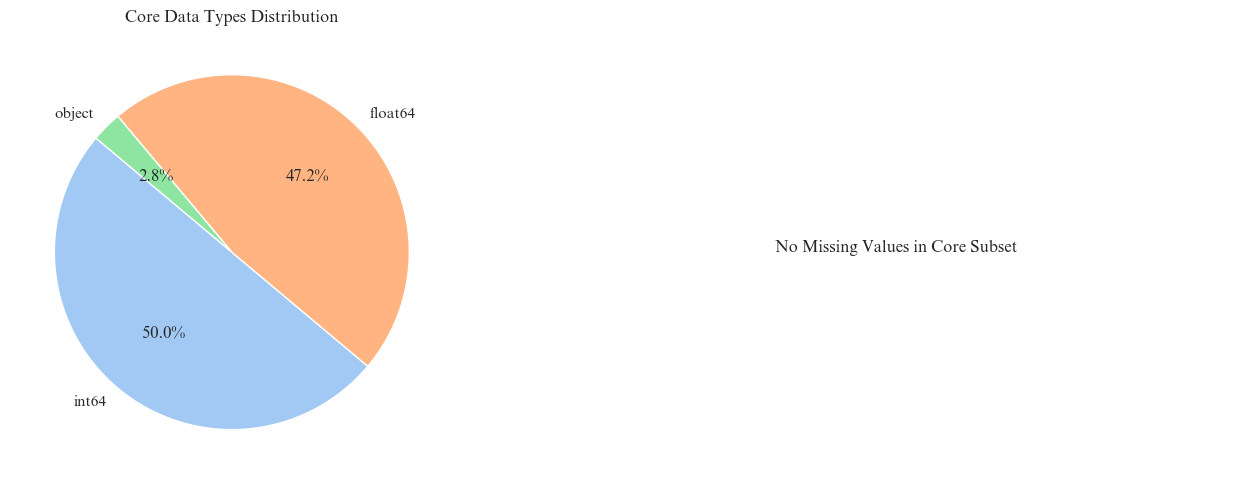

In [2]:
# ------------------------------------------------------------------------------
# Path Setup
# ------------------------------------------------------------------------------
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    # UPDATE THIS PATH FOR COLAB
    BASE_DIR = "/content/drive/MyDrive/cleaned_data"
    RAW_DIR = "/content/drive/MyDrive/widsdatathon2025"
else:
    # Local Path
    BASE_DIR = r"F:\0Master\project\EDA\cleaned_data"
    RAW_DIR = r"F:\0Master\project\EDA\widsdatathon2025"

# ------------------------------------------------------------------------------
# Load CLEANED Data
# ------------------------------------------------------------------------------
print("Loading Cleaned Data for EDA...")

df_clean = None

# Try to find split files in 'cleaned_data/Train' or nested 'cleaned_data/cleaned_data'
# Note: On Colab (Linux), paths are case-sensitive. We search for 'Train' or 'train'.
# STRICTLY LIMIT to TRAIN folder as requested
train_dir_candidates = [
    os.path.join(BASE_DIR, "Train"),
    os.path.join(BASE_DIR, "train"),
    os.path.join(BASE_DIR, "cleaned_data")
]
train_dir = next((d for d in train_dir_candidates if os.path.exists(d)), None)

cleaned_files = []
if train_dir:
    cleaned_files = glob.glob(os.path.join(train_dir, "cleaned_train_*.csv"))
    # Exclude One-Hot Encoded files to avoid duplicates and confusion
    cleaned_files = [f for f in cleaned_files if 'ohe' not in f.lower()]
    print(f"Searching in Train directory: {train_dir}")
else:
    # Fallback: search in BASE_DIR directly if flattened, but filter for 'train' in filename
    print("Train directory not found, searching in BASE_DIR for 'cleaned_train_*.csv'")
    cleaned_files = glob.glob(os.path.join(BASE_DIR, "cleaned_train_*.csv"))

# Locate TRAINING_SOLUTIONS.xlsx (Target Labels)
solutions_path = os.path.join(BASE_DIR, "TRAINING_SOLUTIONS.xlsx")
if os.path.exists(solutions_path):
    cleaned_files.append(solutions_path)
else:
    # Try finding it in the nested cleaned_data folder
    nested_solutions = os.path.join(BASE_DIR, "cleaned_data", "TRAINING_SOLUTIONS.xlsx")
    if os.path.exists(nested_solutions):
        cleaned_files.append(nested_solutions)
    else:
        # Try finding it in the Raw Data folder (TRAIN_NEW)
        raw_solutions = os.path.join(RAW_DIR, "TRAIN_NEW", "TRAINING_SOLUTIONS.xlsx")
        if os.path.exists(raw_solutions):
            print(f"Found Training Solutions in Raw Dir: {raw_solutions}")
            cleaned_files.append(raw_solutions)
        else:
            print("Warning: TRAINING_SOLUTIONS.xlsx not found in cleaned or raw directories. Target variables may be missing.")

print(f"Found {len(cleaned_files)} files to merge.")

dfs_to_merge = []
for fpath in cleaned_files:
    fname = os.path.basename(fpath)
    print(f"Reading: {fname} ...", end=" ")
    try:
        if fpath.endswith('.csv'):
            df_temp = pd.read_csv(fpath)
        elif fpath.endswith('.xlsx'):
            df_temp = pd.read_excel(fpath)
        else:
            continue

        print(f"Shape: {df_temp.shape}")

        # Rename fcm columns if needed
        if 'connectome' in fname.lower():
            new_cols = {}
            for c in df_temp.columns:
                if '0throw' in c:
                    try:
                        idx = c.split('_')[1].replace('thcolumn', '').replace('stcolumn', '').replace('ndcolumn', '').replace('rdcolumn', '')
                        new_cols[c] = f"fcm_{idx}"
                    except:
                        new_cols[c] = c.replace('0throw_', 'fcm_')
            if new_cols:
                df_temp.rename(columns=new_cols, inplace=True)
                print(f"  -> Renamed {len(new_cols)} connectome columns")

        dfs_to_merge.append(df_temp)
    except Exception as e:
        print(f"Failed to read {fname}: {e}")

if dfs_to_merge:
    df_clean = reduce(lambda left, right: pd.merge(left, right, on='participant_id', how='inner'), dfs_to_merge)
    print(f"Cleaned Data Loaded. Final Shape: {df_clean.shape}")

    # --- FIX COLUMN NAMES (Handle merge suffixes like _x, _y) ---
    # Check for Sex_F columns
    sex_cols = [c for c in df_clean.columns if 'Sex' in c]
    print(f"DEBUG: Sex columns found: {sex_cols}")

    # If we have Sex_F_y but not Sex_F, rename it
    if 'Sex_F' not in df_clean.columns and 'Sex_F_y' in df_clean.columns:
        print("Renaming 'Sex_F_y' to 'Sex_F'...")
        df_clean.rename(columns={'Sex_F_y': 'Sex_F'}, inplace=True)
    elif 'Sex_F' not in df_clean.columns and 'Sex_F_x' in df_clean.columns:
        print("Renaming 'Sex_F_x' to 'Sex_F'...")
        df_clean.rename(columns={'Sex_F_x': 'Sex_F'}, inplace=True)

    # Do the same for ADHD_Outcome if needed
    if 'ADHD_Outcome' not in df_clean.columns and 'ADHD_Outcome_y' in df_clean.columns:
        print("Renaming 'ADHD_Outcome_y' to 'ADHD_Outcome'...")
        df_clean.rename(columns={'ADHD_Outcome_y': 'ADHD_Outcome'}, inplace=True)
    elif 'ADHD_Outcome' not in df_clean.columns and 'ADHD_Outcome_x' in df_clean.columns:
        print("Renaming 'ADHD_Outcome_x' to 'ADHD_Outcome'...")
        df_clean.rename(columns={'ADHD_Outcome_x': 'ADHD_Outcome'}, inplace=True)

    print("Columns (first 10):", df_clean.columns.tolist()[:10], "...")
else:
    print("Warning: No cleaned files found. Please check paths.")

if df_clean is not None:
    display(df_clean.head(3))

# ------------------------------------------------------------------------------
# 2.1 Dataset Integrity Check (Cleaned Data)
# ------------------------------------------------------------------------------
if df_clean is not None:
    print("\n--- Dataset Integrity Check (Cleaned Data) ---")

    # Select core columns for basic check
    # Using dynamic selection for groups of variables
    ehq_vars = [c for c in df_clean.columns if 'EHQ' in c]
    apq_vars = [c for c in df_clean.columns if c.startswith('APQ_P_')]
    sdq_vars = [c for c in df_clean.columns if c.startswith('SDQ_SDQ_')]

    core_cols = ['participant_id', 'MRI_Track_Age_at_Scan', 'ColorVision_cv_Score', 'ADHD_Outcome', 'Sex_F'] + ehq_vars + apq_vars + sdq_vars
    # Filter only existing columns
    core_cols = [c for c in core_cols if c in df_clean.columns]

    core_df = df_clean[core_cols]

    print(f"Core Subset Shape: {core_df.shape}")
    print(f"Duplicate Rows: {core_df.duplicated().sum()}")

    # Missing Values Table
    missing_core = core_df.isna().sum()
    missing_core_df = pd.DataFrame({
        'Missing Count': missing_core,
        'Missing Ratio': missing_core / len(core_df)
    }).sort_values('Missing Ratio', ascending=False)
    print("\nMissing Values in Core Variables:")
    display(missing_core_df[missing_core_df['Missing Count'] > 0])

    # Data Types Overview
    print("\nData Types Overview:")
    display(core_df.dtypes.value_counts())
    num_cols_core = core_df.select_dtypes(include=np.number).columns
    cat_cols_core = core_df.select_dtypes(exclude=np.number).columns
    print(f"Summary: {len(num_cols_core)} numeric features ({len(num_cols_core)/len(core_cols):.1%}) and {len(cat_cols_core)} categorical/object features.")

    # Memory Usage
    mem_usage = core_df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory Usage for Core Variables: {mem_usage:.2f} MB")

    # --- VISUALIZATION FOR INTEGRITY CHECK ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Data Types Pie Chart
    type_counts = core_df.dtypes.apply(lambda x: x.name).value_counts()
    ax[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    ax[0].set_title('Core Data Types Distribution')

    # 2. Missing Values Bar Chart (Top 10 of Core)
    if not missing_core_df.empty and missing_core_df['Missing Count'].sum() > 0:
        sns.barplot(x='Missing Ratio', y=missing_core_df.index[:10], data=missing_core_df.iloc[:10], ax=ax[1], palette='Reds_r')
        ax[1].set_title('Missing Ratio (Core Variables)')
        ax[1].set_xlabel('Ratio')
    else:
        ax[1].text(0.5, 0.5, 'No Missing Values in Core Subset', ha='center', fontsize=12)
        ax[1].axis('off')

    plt.tight_layout()
    plt.show()


## 3. Missing Value Analysis (Raw)
Analyzing missing values in the original raw data.

Loading Raw Data from widsdatathon2025 (TRAIN_NEW)...
Searching in: /content/drive/MyDrive/widsdatathon2025/TRAIN_NEW
Reading Raw: TRAIN_CATEGORICAL_METADATA_new.xlsx ... OK ((1213, 10))
Reading Raw: TRAIN_QUANTITATIVE_METADATA_new.xlsx ... OK ((1213, 19))
Reading Raw: TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv ... OK ((1213, 19901))

Raw Data Merged. Shape: (1213, 19928)

--- Top 20 Columns with Missing Values (Raw Data) ---


,Missing Count,Missing Percentage
MRI_Track_Age_at_Scan,360,29.678483
Barratt_Barratt_P2_Occ,222,18.301731
Barratt_Barratt_P2_Edu,198,16.323166
PreInt_Demos_Fam_Child_Race,54,4.451772
PreInt_Demos_Fam_Child_Ethnicity,43,3.544930
Barratt_Barratt_P1_Occ,31,2.555647
ColorVision_CV_Score,23,1.896125
Barratt_Barratt_P1_Edu,15,1.236603
EHQ_EHQ_Total,13,1.071723
APQ_P_APQ_P_PP,12,0.989283


/tmp/ipykernel_454/513070609.py:139: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('magma_r')


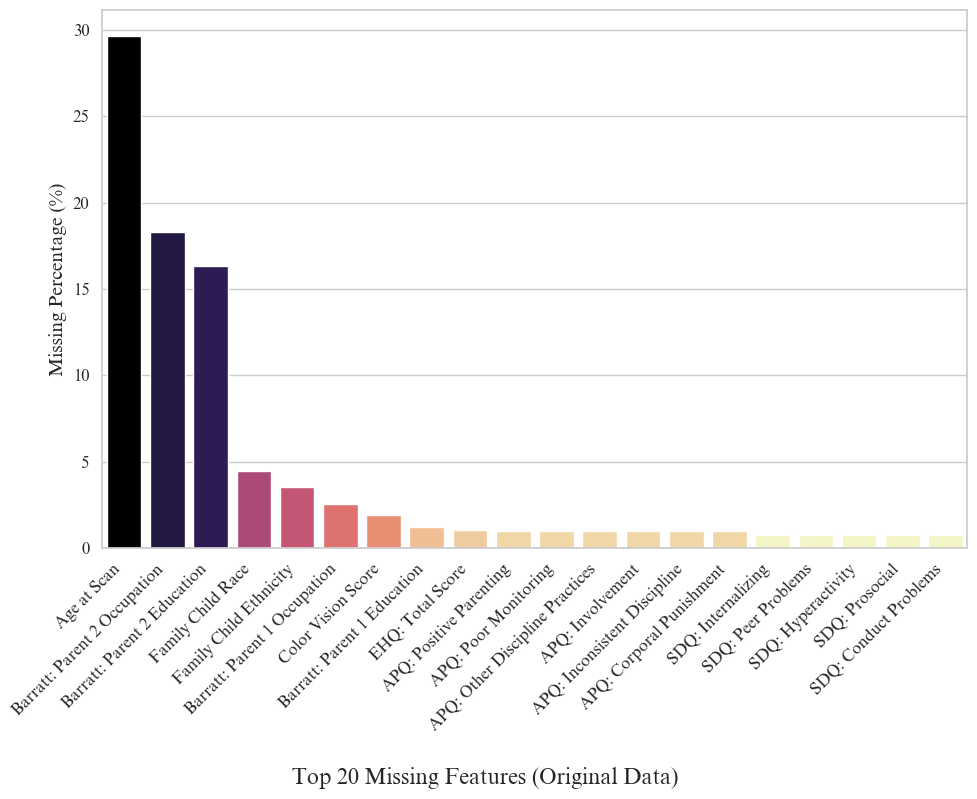

In [3]:
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# Load RAW Data for Missing Value Analysis (TRAIN_NEW only)
# ------------------------------------------------------------------------------
print("Loading Raw Data from widsdatathon2025 (TRAIN_NEW)...")

# STRICTLY LIMIT to TRAIN_NEW folder as requested
raw_train_new_dir = os.path.join(RAW_DIR, "TRAIN_NEW")

if os.path.exists(raw_train_new_dir):
    raw_files_pattern = os.path.join(raw_train_new_dir, "TRAIN_*.xlsx")
    raw_csv_pattern = os.path.join(raw_train_new_dir, "TRAIN_*.csv")

    raw_files = glob.glob(raw_files_pattern) + glob.glob(raw_csv_pattern)
    print(f"Searching in: {raw_train_new_dir}")
else:
    print(f"Warning: Directory {raw_train_new_dir} not found. Searching recursively in RAW_DIR for TRAIN_NEW...")
    raw_files = glob.glob(os.path.join(RAW_DIR, "**", "TRAIN_NEW", "TRAIN_*.xlsx"), recursive=True) + \
                glob.glob(os.path.join(RAW_DIR, "**", "TRAIN_NEW", "TRAIN_*.csv"), recursive=True)

# Filter to keep only likely primary files (ignore temp or macos files)
# And ensure they are TRAIN files
raw_files = [f for f in raw_files if "~$" not in f and "MACOSX" not in f and "TRAIN" in os.path.basename(f)]

# We want to merge them to check missingness globally
dfs_raw_list = []

for fpath in raw_files:
    fname = os.path.basename(fpath)
    # We skip TRAINING_SOLUTIONS for missing analysis as it's the target
    if "SOLUTIONS" in fname:
        continue

    print(f"Reading Raw: {fname} ...", end=" ")
    try:
        if fpath.endswith('.xlsx'):
            df_r = pd.read_excel(fpath)
        else:
            df_r = pd.read_csv(fpath)

        # Check if participant_id exists (key for merging)
        if 'participant_id' in df_r.columns:
            dfs_raw_list.append(df_r)
            print(f"OK ({df_r.shape})")
        else:
            print("Skipped (No participant_id)")
    except Exception as e:
        print(f"Error reading {fname}: {e}")

# Merge Raw Data
if dfs_raw_list:
    df_raw = reduce(lambda left, right: pd.merge(left, right, on='participant_id', how='outer'), dfs_raw_list)
    print(f"\nRaw Data Merged. Shape: {df_raw.shape}")

    # --- Analysis ---
    print("\n--- Top 20 Columns with Missing Values (Raw Data) ---")
    missing_raw = df_raw.isnull().sum()
    missing_raw_stats = pd.DataFrame({
        'Missing Count': missing_raw,
        'Missing Percentage': (missing_raw / len(df_raw)) * 100
    }).sort_values('Missing Percentage', ascending=False)

    display(missing_raw_stats.head(20))

    # Plot
    plt.figure(figsize=(10, 8))

    # Use percentage for plotting
    top_missing = missing_raw_stats.head(20).copy()

    # Clean Labels Function
    def clean_label(label):
        # Exact/Specific match mappings based on Data Dictionary
        mapping = {
            'Barratt_Barratt_P1_Edu': 'Barratt: Parent 1 Education',
            'Barratt_Barratt_P1_Occ': 'Barratt: Parent 1 Occupation',
            'Barratt_Barratt_P2_Edu': 'Barratt: Parent 2 Education',
            'Barratt_Barratt_P2_Occ': 'Barratt: Parent 2 Occupation',
            'APQ_P_APQ_P_CP': 'APQ: Corporal Punishment',
            'APQ_P_APQ_P_ID': 'APQ: Inconsistent Discipline',
            'APQ_P_APQ_P_INV': 'APQ: Involvement',
            'APQ_P_APQ_P_OPD': 'APQ: Other Discipline Practices',
            'APQ_P_APQ_P_PM': 'APQ: Poor Monitoring',
            'APQ_P_APQ_P_PP': 'APQ: Positive Parenting',
            'ColorVision_CV_Score': 'Color Vision Score',
            'EHQ_EHQ_Total': 'EHQ: Total Score',
            'SDQ_SDQ_Conduct_Problems': 'SDQ: Conduct Problems',
            'SDQ_SDQ_Difficulties_Total': 'SDQ: Total Difficulties',
            'SDQ_SDQ_Emotional_Problems': 'SDQ: Emotional Problems',
            'SDQ_SDQ_Externalizing': 'SDQ: Externalizing',
            'SDQ_SDQ_Generating_Impact': 'SDQ: Generating Impact',
            'SDQ_SDQ_Hyperactivity': 'SDQ: Hyperactivity',
            'SDQ_SDQ_Internalizing': 'SDQ: Internalizing',
            'SDQ_SDQ_Peer_Problems': 'SDQ: Peer Problems',
            'SDQ_SDQ_Prosocial': 'SDQ: Prosocial',
            'PreInt_Demos_Fam_Child_Race': 'Family Child Race',
            'PreInt_Demos_Fam_Child_Ethnicity': 'Family Child Ethnicity',
            'Basic_Demos_Age': 'Age at Scan'
        }

        if label in mapping:
            return mapping[label]

        # Fallback for others not explicitly in mapping
        # Remove duplicated prefixes (e.g., Barratt_Barratt_ -> Barratt_)
        import re
        label = re.sub(r'^([A-Za-z]+)_\1_', r'\1_', label)

        # Common prefix cleanup
        label = label.replace('APQ_P_', 'APQ: ')
        label = label.replace('SDQ_', 'SDQ: ')
        label = label.replace('PreInt_Demos_Fam_', 'Family: ')
        label = label.replace('PreInt_Edu_Hx_', 'Edu History: ')
        label = label.replace('MRI_Track_', 'MRI: ')
        label = label.replace('PCIAT_', 'PCIAT: ')
        label = label.replace('Barratt_', 'Barratt: ')
        label = label.replace('ColorVision_', 'Color Vision: ')

        # General cleanup
        label = label.replace('_', ' ')

        # Specific overrides if needed
        if 'Age at Scan' in label: return 'Age at Scan'

        # Clean up repeated colons or spaces
        label = label.replace(': :', ':')
        label = re.sub(r'\s+', ' ', label)

        return label.strip()

    # Apply cleaning
    top_missing['Clean Labels'] = top_missing.index.map(clean_label)

    # --- Gradient Logic Fix (Logarithmic Scale) ---
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    # Use reversed magma colormap (higher values = darker/blacker)
    cmap = cm.get_cmap('magma_r')

    # Use LogNorm to spread out low values visually
    # vmin needs to be > 0. If min is 0, use a small epsilon like 0.1
    min_val = max(0.1, top_missing['Missing Percentage'].min())
    max_val = top_missing['Missing Percentage'].max()

    norm = mcolors.LogNorm(vmin=min_val, vmax=max_val)

    # Generate explicit color list
    bar_colors = [cmap(norm(max(0.1, val))) for val in top_missing['Missing Percentage']]

    # Create palette dict for hue mapping safety
    palette_dict = {idx: color for idx, color in zip(top_missing.index, bar_colors)}

    sns.barplot(x='Clean Labels', y='Missing Percentage', hue=top_missing.index, data=top_missing, palette=palette_dict, legend=False)
    # Increase font size for axis ticks and labels
    plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12)
    plt.xlabel('', fontsize=14, fontweight='bold')
    plt.ylabel('Missing Percentage (%)', fontsize=14, fontweight='bold')
    plt.title("") # Remove top title

    # Add title at the bottom with larger font
    plt.figtext(0.5, 0.01, "Top 20 Missing Features (Original Data)", ha='center', fontsize=16, fontweight='bold')

    # Adjust layout to make room for bottom title
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

else:
    print("Could not load raw data for missing value analysis.")


## 4. Target Analysis
Distribution of ADHD Outcome and Sex.

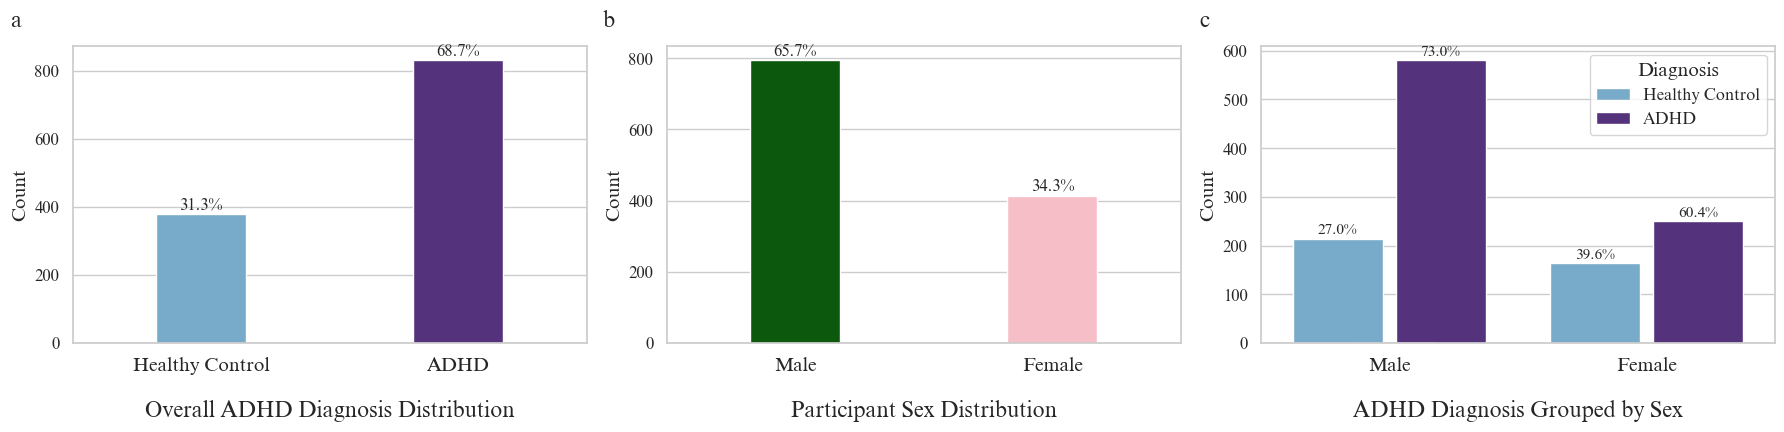

In [8]:
if df_clean is not None:
    df_target = df_clean  # Alias for clarity
    total = len(df_target)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Add Nature style panel labels (a, b, c)
    import string
    panel_labels = list(string.ascii_lowercase)
    for i, ax in enumerate(axes):
        ax.text(-0.1, 1.05, panel_labels[i], transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='right')

    def change_bar_width(ax, new_value):
        for patch in ax.patches:
            current_width = patch.get_width()
            diff = current_width - new_value
            patch.set_width(new_value)
            patch.set_x(patch.get_x() + diff * .5)

    # Overall Distribution
    adhd_palette = {0: COLOR_HEALTHY, 1: COLOR_ADHD}
    sns.countplot(x='ADHD_Outcome', data=df_target, palette=adhd_palette, ax=axes[0], hue='ADHD_Outcome', legend=False)
    change_bar_width(axes[0], 0.35)
    # Remove sub-titles to adhere to caption-style at bottom
    axes[0].set_title('')
    axes[0].set_xlabel('') # Clear X label since title is at bottom
    axes[0].text(0.5, -0.25, 'Overall ADHD Diagnosis Distribution', transform=axes[0].transAxes, ha='center', fontsize=16, fontweight='bold')

    # Set ticks before labels to avoid warnings
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Healthy Control', 'ADHD'], fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='y', labelsize=12)

    # Add percentage labels
    total = len(df_target)
    for p in axes[0].patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            axes[0].text(p.get_x() + p.get_width()/2., height + 5,
                    f'{height/total:.1%}', ha="center", va='bottom', fontsize=12, fontweight='bold')

    # Sex Distribution
    sns.countplot(x='Sex_F', data=df_target, palette=[COLOR_MALE, COLOR_FEMALE], ax=axes[1], hue='Sex_F', legend=False)
    change_bar_width(axes[1], 0.35)
    axes[1].set_title('')
    axes[1].set_xlabel('')
    axes[1].text(0.5, -0.25, 'Participant Sex Distribution', transform=axes[1].transAxes, ha='center', fontsize=16, fontweight='bold')
    axes[1].set_ylabel('Count', fontsize=14, fontweight='bold')
    axes[1].tick_params(axis='y', labelsize=12)
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(['Male', 'Female'], fontsize=14, fontweight='bold')

    for p in axes[1].patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            axes[1].text(p.get_x() + p.get_width()/2., height + 5,
                    f'{height/total:.1%}', ha="center", va='bottom', fontsize=12, fontweight='bold')

    # ADHD by Sex
    # Create a cross-tabulation for proportional representation
    # This is often more informative than raw counts for interaction
    ct = pd.crosstab(df_target['Sex_F'], df_target['ADHD_Outcome'], normalize='index')

    # Alternatively, keep countplot if raw counts are preferred, but proportion shows the effect better
    # Let's stick to countplot but add proportions as text
    sns.countplot(
        x='Sex_F',
        hue='ADHD_Outcome',
        data=df_target,
        palette=adhd_palette,
        ax=axes[2]
    )
    change_bar_width(axes[2], 0.35)

    axes[2].set_title('')
    axes[2].set_ylabel('Count', fontsize=14, fontweight='bold')
    axes[2].tick_params(axis='y', labelsize=12)
    axes[2].set_xlabel('')
    axes[2].text(0.5, -0.25, 'ADHD Diagnosis Grouped by Sex', transform=axes[2].transAxes, ha='center', fontsize=16, fontweight='bold')

    axes[2].set_xticks([0, 1])
    axes[2].set_xticklabels(['Male', 'Female'], fontsize=14, fontweight='bold')

    # Legend handling for ax3
    handles, labels = axes[2].get_legend_handles_labels()
    # Ensure legend is present for C
    axes[2].legend(handles=handles, labels=['Healthy Control', 'ADHD'], title='Diagnosis', loc='upper right', fontsize=12, title_fontsize=14)

    # Add percentage labels within groups
    for i, sex_val in enumerate([0, 1]):
        group_total = len(df_target[df_target['Sex_F'] == sex_val])
        if group_total > 0:
            for j, p in enumerate(axes[2].patches[i::2]): # Iterate through hue patches
                height = p.get_height()
                if not np.isnan(height) and height > 0:
                    axes[2].text(p.get_x() + p.get_width()/2., height + 5,
                            f'{height/group_total:.1%}', ha="center", va='bottom', fontsize=11, fontweight='bold')

    # Add single global title at the bottom - Removed as requested
    # plt.figtext(0.5, 0.01, "Demographic and Target Variables Analysis", ha='center', fontsize=16, fontweight='bold')

    # Adjust layout to make room for bottom title
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


## 5. Feature EDA: Demographics & Quantitative
Analysis of key demographic and behavioral features.

Main Numeric Features: 56

--- Numeric Summary Statistics (Key Features) ---


,Variable,Mean,Std,Median,Min,Max,IQR,CV,Distinct Values
Clean Variable,,,,,,,,,
Age at Scan,MRI_Track_Age_at_Scan,11.107696,2.724580,10.660049,0.0,21.564453,2.365846,0.245288,839
EHQ: Total Score,EHQ_EHQ_Total,59.700108,49.488407,77.800000,-100.0,100.000000,46.685000,0.828950,158
APQ: Corporal Punishment,APQ_P_APQ_P_CP,3.812914,1.328335,3.000000,2.0,12.000000,1.000000,0.348378,10
APQ: Inconsistent Discipline,APQ_P_APQ_P_ID,13.338576,3.577352,13.000000,5.0,28.000000,5.000000,0.268196,21
APQ: Involvement,APQ_P_APQ_P_INV,39.766556,4.857042,40.000000,23.0,50.000000,7.000000,0.122139,26
APQ: Other Discipline Practices,APQ_P_APQ_P_OPD,17.958609,3.319737,18.000000,7.0,28.000000,4.000000,0.184855,21
APQ: Poor Monitoring,APQ_P_APQ_P_PM,16.534768,5.122407,16.000000,5.0,37.000000,6.000000,0.309796,30
APQ: Positive Parenting,APQ_P_APQ_P_PP,25.502483,3.041687,26.000000,13.0,30.000000,5.000000,0.119270,18
SDQ: Conduct Problems,SDQ_SDQ_Conduct_Problems,2.072434,2.020178,2.000000,0.0,10.000000,3.000000,0.974785,12


/tmp/ipykernel_454/3765265908.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


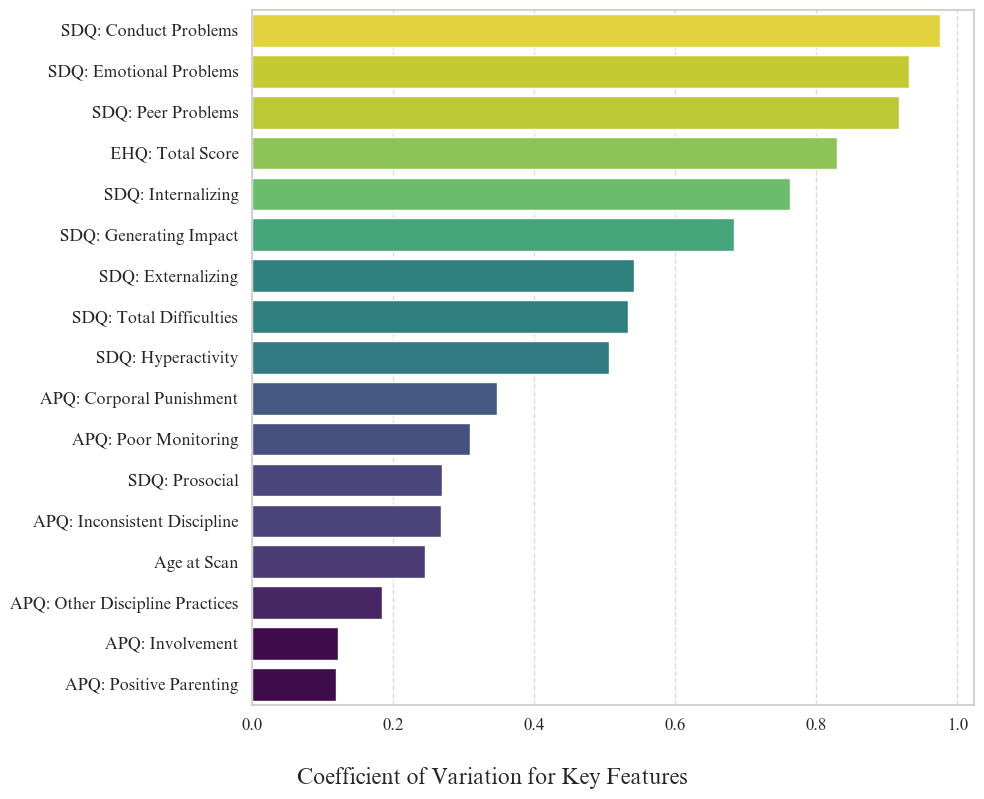


Checking potential outliers/ranges for specific features:

EHQ_EHQ_Total (Min: -100.00, Max: 100.00, Median: 77.80)

MRI_Track_Age_at_Scan (Min: 0.00, Max: 21.56, Median: 10.66)

--- Key Feature Distributions ---


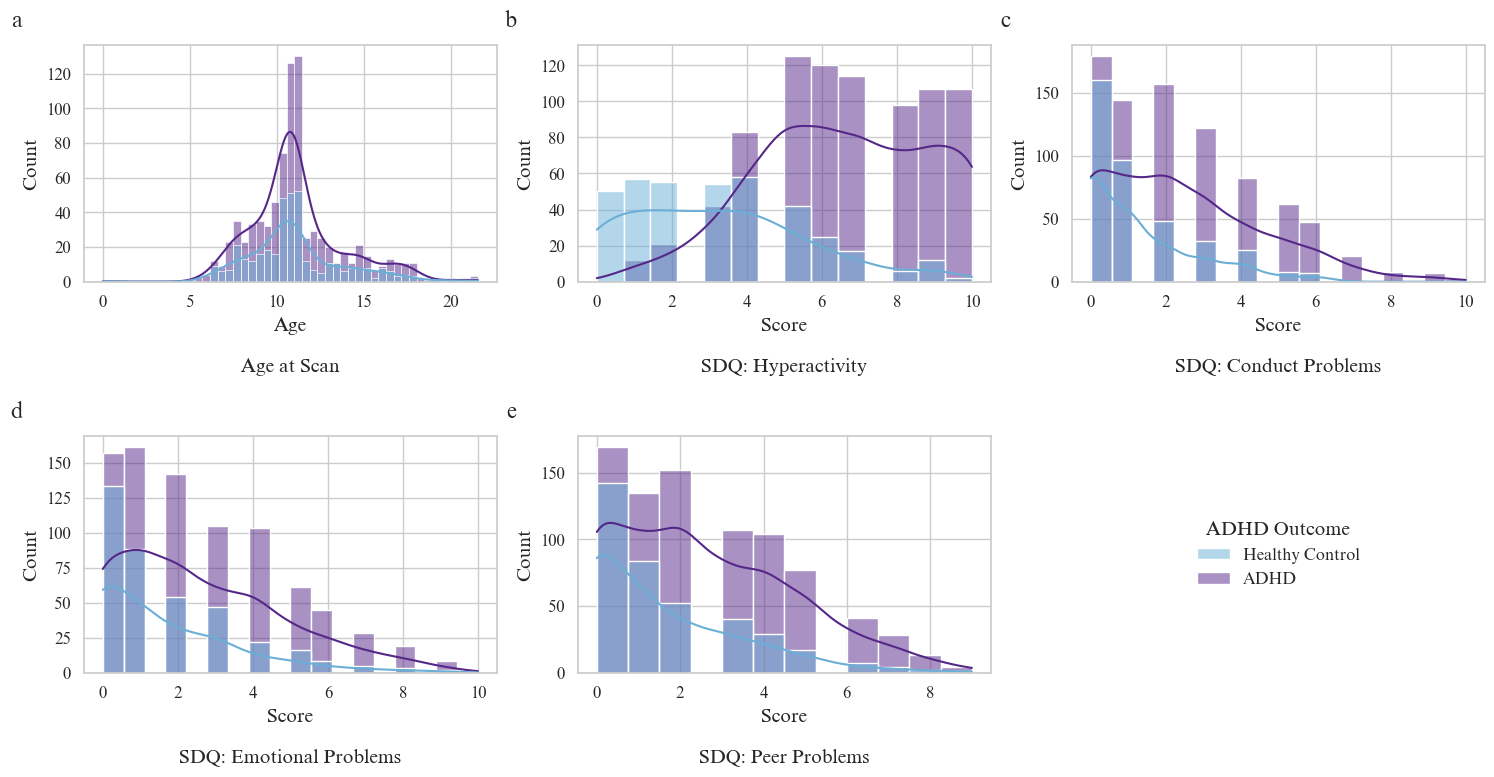


--- Correlation Analysis ---


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


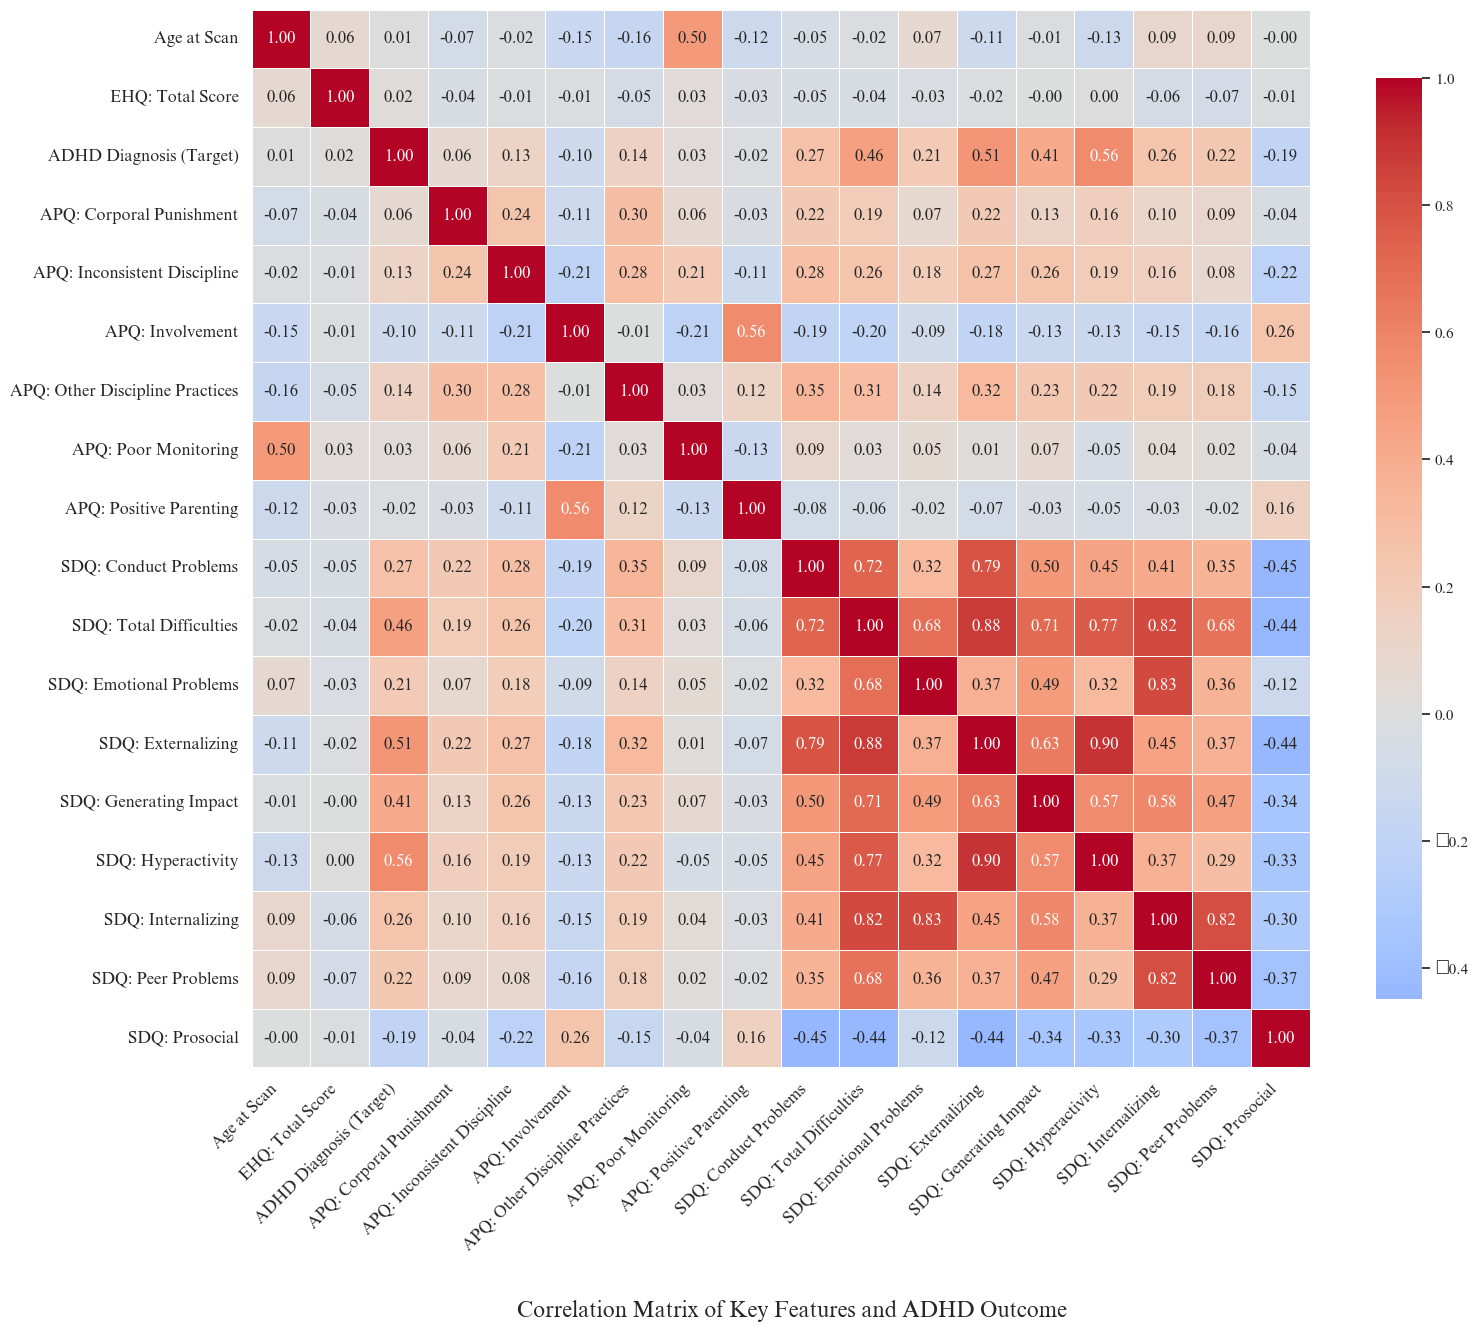

/tmp/ipykernel_454/3765265908.py:361: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')
/tmp/ipykernel_454/3765265908.py:384: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


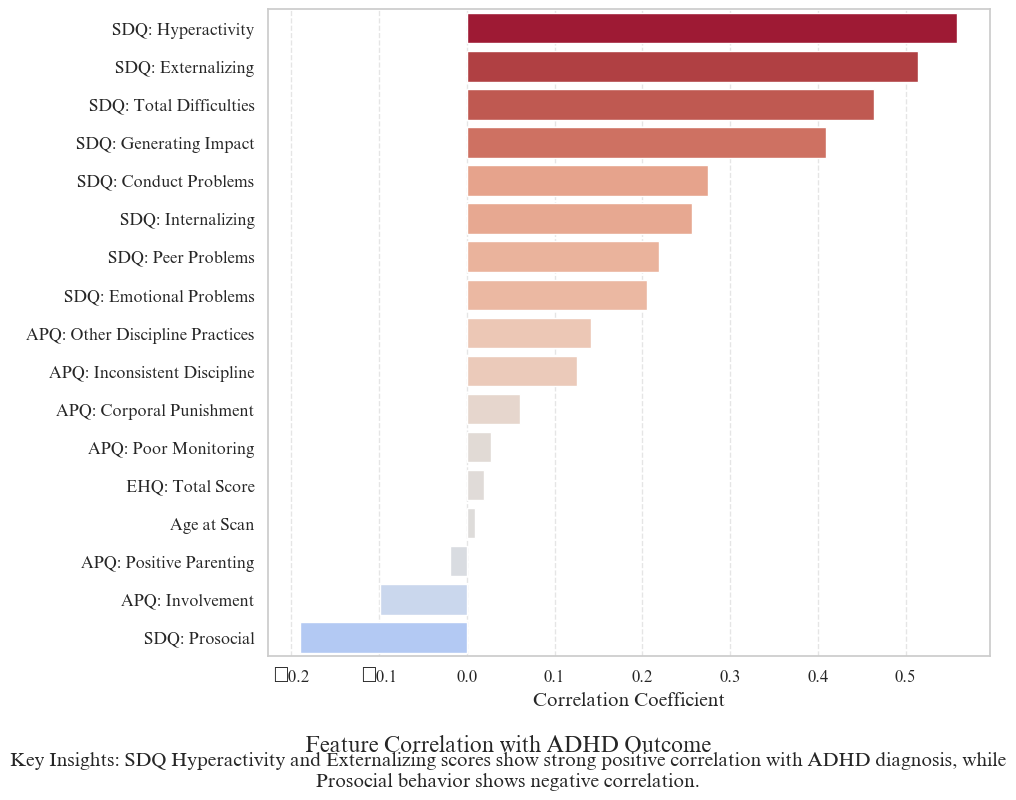

In [5]:
if df_clean is not None:
    # Identify columns
    id_col = 'participant_id'
    target_cols = ['ADHD_Outcome', 'Sex_F']
    numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()

    # Exclude IDs, Targets, and FCM columns for cleaner univariate plots
    main_numeric = [c for c in numeric_features
                   if c not in target_cols
                   and not c.startswith('fcm_')
                   and not c.startswith('0throw')
                   and 'throw' not in c
                   and 'column' not in c]

    print(f"Main Numeric Features: {len(main_numeric)}")

    # Helper to clean labels
    def clean_label_simple(label):
        # Exact/Specific match mappings based on Data Dictionary
        mapping = {
            'Barratt_Barratt_P1_Edu': 'Barratt: Parent 1 Education',
            'Barratt_Barratt_P1_Occ': 'Barratt: Parent 1 Occupation',
            'Barratt_Barratt_P2_Edu': 'Barratt: Parent 2 Education',
            'Barratt_Barratt_P2_Occ': 'Barratt: Parent 2 Occupation',
            'APQ_P_APQ_P_CP': 'APQ: Corporal Punishment',
            'APQ_P_APQ_P_ID': 'APQ: Inconsistent Discipline',
            'APQ_P_APQ_P_INV': 'APQ: Involvement',
            'APQ_P_APQ_P_OPD': 'APQ: Other Discipline Practices',
            'APQ_P_APQ_P_PM': 'APQ: Poor Monitoring',
            'APQ_P_APQ_P_PP': 'APQ: Positive Parenting',
            'ColorVision_cv_Score': 'Color Vision Score',
            'ColorVision_CV_Score': 'Color Vision Score',
            'EHQ_EHQ_Total': 'EHQ: Total Score',
            'SDQ_SDQ_Conduct_Problems': 'SDQ: Conduct Problems',
            'SDQ_SDQ_Difficulties_Total': 'SDQ: Total Difficulties',
            'SDQ_SDQ_Emotional_Problems': 'SDQ: Emotional Problems',
            'SDQ_SDQ_Externalizing': 'SDQ: Externalizing',
            'SDQ_SDQ_Generating_Impact': 'SDQ: Generating Impact',
            'SDQ_SDQ_Hyperactivity': 'SDQ: Hyperactivity',
            'SDQ_SDQ_Internalizing': 'SDQ: Internalizing',
            'SDQ_SDQ_Peer_Problems': 'SDQ: Peer Problems',
            'SDQ_SDQ_Prosocial': 'SDQ: Prosocial',
            'PreInt_Demos_Fam_Child_Race': 'Family Child Race',
            'PreInt_Demos_Fam_Child_Ethnicity': 'Family Child Ethnicity',
            'MRI_Track_Age_at_Scan': 'Age at Scan',
            'ADHD_Outcome': 'ADHD Diagnosis (Target)',
            'Sex_F': 'Biological Sex'
        }

        if label in mapping:
            return mapping[label]

        import re
        label = re.sub(r'^([A-Za-z]+)_\1_', r'\1_', label)

        label = label.replace('APQ_P_', 'APQ: ')
        label = label.replace('SDQ_SDQ_', 'SDQ: ')
        label = label.replace('SDQ_', 'SDQ: ')
        label = label.replace('PreInt_Demos_Fam_', 'Family: ')
        label = label.replace('PreInt_Edu_Hx_', 'Edu History: ')
        label = label.replace('EHQ_EHQ_', 'EHQ: ')
        label = label.replace('MRI_Track_', 'MRI: ')
        label = label.replace('ColorVision_cv_', 'Color Vision: ')
        label = label.replace('ColorVision_', 'Color Vision: ')
        label = label.replace('_', ' ')

        label = label.replace(': :', ':')
        label = re.sub(r'\s+', ' ', label)

        return label.strip()

    # ------------------------------------------------------------------------------
    # 5.1 Numeric Summary Statistics (Key 18 Features)
    # ------------------------------------------------------------------------------
    key_numeric = ['MRI_Track_Age_at_Scan', 'EHQ_EHQ_Total', 'ColorVision_cv_Score']
    key_numeric += [c for c in df_clean.columns if c.startswith('APQ_P_') and not c.endswith('__missing_ind')]
    key_numeric += [c for c in df_clean.columns if c.startswith('SDQ_SDQ_') and not c.endswith('__missing_ind')]
    key_numeric = [c for c in key_numeric if c in df_clean.columns]

    if key_numeric:
        print("\n--- Numeric Summary Statistics (Key Features) ---")
        stats_list = []
        for col in key_numeric:
            s = df_clean[col]
            stats_list.append({
                'Variable': col,
                'Clean Variable': clean_label_simple(col),
                'Mean': s.mean(),
                'Std': s.std(),
                'Median': s.median(),
                'Min': s.min(),
                'Max': s.max(),
                'IQR': s.quantile(0.75) - s.quantile(0.25),
                'CV': s.std() / s.mean() if s.mean() != 0 else np.nan,
                'Distinct Values': s.nunique()
            })

        summary_df = pd.DataFrame(stats_list).set_index('Clean Variable') # Use clean labels as index
        display(summary_df)

        plt.figure(figsize=(10, 8))
        # Sorted Descending
        summary_sorted = summary_df.sort_values('CV', ascending=False)

        # Use gradient colormap (viridis) based on CV value
        # Map values to colors explicitly
        norm = plt.Normalize(summary_sorted['CV'].min(), summary_sorted['CV'].max())
        import matplotlib.cm as cm
        cmap = cm.get_cmap('viridis')
        bar_colors = [cmap(norm(val)) for val in summary_sorted['CV']]

        # Use palette dict
        palette_dict = {idx: color for idx, color in zip(summary_sorted.index, bar_colors)}

        sns.barplot(x='CV', y=summary_sorted.index, data=summary_sorted, palette=palette_dict, hue=summary_sorted.index, legend=False)

        plt.title('') # Remove top title
        plt.xlabel('') # Removed CV (Std / Mean) as requested
        plt.ylabel('')
        plt.grid(axis='x', linestyle='--', alpha=0.7)

        # Increase tick label size
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12, fontweight='bold')

        # Add title at bottom with larger font
        plt.figtext(0.5, 0.01, 'Coefficient of Variation for Key Features', ha='center', fontsize=16, fontweight='bold')

        # Adjust layout to make room for bottom title
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

        check_cols = ['EHQ_EHQ_Total', 'ColorVision_cv_Score', 'MRI_Track_Age_at_Scan']
        print("\nChecking potential outliers/ranges for specific features:")
        for c in check_cols:
            if c in df_clean.columns:
                desc = df_clean[c].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
                print(f"\n{c} (Min: {desc['min']:.2f}, Max: {desc['max']:.2f}, Median: {desc['50%']:.2f})")

    if df_clean is not None:
        print("\n--- Key Feature Distributions ---")

        # sns.set_style("whitegrid") # Removed to prevent font reset

        selected_features = [
            'MRI_Track_Age_at_Scan',
            'SDQ_SDQ_Hyperactivity',
            'SDQ_SDQ_Conduct_Problems',
            'SDQ_SDQ_Emotional_Problems',
            'SDQ_SDQ_Peer_Problems'
        ]

        missing_features = [c for c in selected_features if c not in df_clean.columns]
        if missing_features:
            print(f"Warning: The following requested features are missing from the dataframe: {missing_features}")
            print("Please check if the 'cleaned_train_categorical.csv' file was loaded correctly.")

        selected_features = [c for c in selected_features if c in df_clean.columns]

        # Categorical mappings no longer strictly needed for these 5, but kept for safety
        categorical_mappings = {
            'PreInt_Demos_Fam_Child_Ethnicity': {
                0: 'Not Hispanic/Latino', 1: 'Hispanic/Latino', 2: 'Decline', 3: 'Unknown'
            },
            'PreInt_Demos_Fam_Child_Race': {
                0: 'White', 1: 'Black/African Am.', 2: 'Hispanic', 3: 'Asian', 4: 'Indian',
                5: 'Native Am.', 6: 'Am. Indian/Alaskan', 7: 'Pacific Islander',
                8: 'Two+ Races', 9: 'Other', 10: 'Unknown', 11: 'Choose not to specify'
            },
            'Sex_F': {0: 'Male', 1: 'Female'}
        }

        n_plot = len(selected_features)
        # Nature style often prefers compact layouts, let's use 2 rows x 3 cols for 5 plots
        rows = 2
        cols = 3

        def get_clean_title(col_name):
            # Already mapped cleanly using clean_label_simple
            return clean_label_simple(col_name)

        plot_df = df_clean.copy()
        if 'ADHD_Outcome' in plot_df.columns:
            plot_df['ADHD_Label'] = plot_df['ADHD_Outcome'].map({0: 'Healthy Control', 1: 'ADHD'})
        else:
            plot_df['ADHD_Label'] = 'Unknown'

        # Nature style figure size
        fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
        axes = axes.flatten()

        global_handles = None
        global_labels = None

        adhd_palette = {'Healthy Control': COLOR_HEALTHY, 'ADHD': COLOR_ADHD}

        # Panel labels for Nature style (a, b, c, d, e)
        import string
        panel_labels = list(string.ascii_lowercase)

        for i, col in enumerate(selected_features):
            ax = axes[i]

            if col in categorical_mappings:
                plot_df[f'{col}_mapped'] = plot_df[col].map(categorical_mappings[col])

                sns.histplot(
                    y=f'{col}_mapped',
                    data=plot_df,
                    hue='ADHD_Label',
                    ax=ax,
                    palette=adhd_palette,
                    hue_order=['Healthy Control', 'ADHD'],
                    multiple="dodge",
                    element="bars",
                    shrink=0.8,
                    edgecolor='white'
                )
                # Nature style: Title on top -> Changed to bottom
                ax.set_title("")
                ax.set_xlabel(f"Count\n\n{get_clean_title(col)}", fontsize=14, fontweight='bold')
                # Remove y label to clean up
                ax.set_ylabel("")
            else:
                sns.histplot(
                    data=plot_df,
                    x=col,
                    hue='ADHD_Label',
                    kde=True,
                    ax=ax,
                    palette=adhd_palette,
                    hue_order=['Healthy Control', 'ADHD'],
                    element="bars",
                    edgecolor='white',
                    common_norm=False
                )
                # Nature style: Title on top -> Changed to bottom
                ax.set_title("")
                # Keep X-axis clean or use a simpler label since title has it
                # For age, use "Age", for others (surveys) use "Score"
                if "Age" in get_clean_title(col):
                    ax.set_xlabel(f"Age\n\n{get_clean_title(col)}", fontsize=14, fontweight='bold')
                else:
                    ax.set_xlabel(f"Score\n\n{get_clean_title(col)}", fontsize=14, fontweight='bold')

                # Clean up Y-axis label to be uniform
                ax.set_ylabel("Count", fontsize=14, fontweight='bold')
                # Increase tick params
                ax.tick_params(axis='both', which='major', labelsize=12)

            # Add Nature style panel label (a, b, c, d...)
            # Move the label slightly higher and more to the left so it doesn't overlap the title
            ax.text(-0.15, 1.15, panel_labels[i], transform=ax.transAxes,
                    fontsize=16, fontweight='bold', va='top', ha='right')

            # Extract legend from first plot only
            if i == 0 and ax.legend_:
                global_handles, global_labels = ax.get_legend_handles_labels()
                if not global_handles and ax.legend_:
                    global_handles = ax.legend_.legend_handles
                    global_labels = [t.get_text() for t in ax.legend_.texts]

            if ax.legend_:
                ax.legend_.remove()

        # Turn off unused axes
        for j in range(i+1, len(axes)):
            axes[j].axis('off')

        if global_handles:
            # Nature style: single clear legend, usually inside an empty panel or at top
            # We'll put it in the empty 6th panel (index 5)
            axes[5].legend(global_handles, global_labels, loc='center', title="ADHD Outcome", frameon=False, fontsize=12, title_fontsize=14)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------------------
    # Correlation Analysis (Appended)
    # ------------------------------------------------------------------------------
    if df_clean is not None:
        print("\n--- Correlation Analysis ---")

        target_col = 'ADHD_Outcome'

        corr_cols_ordered = [
            'MRI_Track_Age_at_Scan',
            'EHQ_EHQ_Total',
            'ADHD_Outcome',
            'APQ_P_APQ_P_CP',
            'APQ_P_APQ_P_ID',
            'APQ_P_APQ_P_INV',
            'APQ_P_APQ_P_OPD',
            'APQ_P_APQ_P_PM',
            'APQ_P_APQ_P_PP',
            'SDQ_SDQ_Conduct_Problems',
            'SDQ_SDQ_Difficulties_Total',
            'SDQ_SDQ_Emotional_Problems',
            'SDQ_SDQ_Externalizing',
            'SDQ_SDQ_Generating_Impact',
            'SDQ_SDQ_Hyperactivity',
            'SDQ_SDQ_Internalizing',
            'SDQ_SDQ_Peer_Problems',
            'SDQ_SDQ_Prosocial'
        ]

        corr_cols = [c for c in corr_cols_ordered if c in df_clean.columns]
        corr_matrix = df_clean[corr_cols].corr()

        # Clean Labels for Heatmap
        clean_labels_corr = [clean_label_simple(c) for c in corr_matrix.columns]

        plt.figure(figsize=(16, 14))
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm', # Diverging academic map
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 12, "weight": "bold"}, # Increase annotation font size
            xticklabels=clean_labels_corr,
            yticklabels=clean_labels_corr
        )
        plt.title('') # Remove top title

        # Increase axis label size for heatmap
        plt.xticks(fontsize=12, fontweight='bold', rotation=45, ha='right')
        plt.yticks(fontsize=12, fontweight='bold')

        # Add title at bottom
        plt.figtext(0.5, 0.02, 'Correlation Matrix of Key Features and ADHD Outcome', ha='center', fontsize=16, fontweight='bold')

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()

        plt.figure(figsize=(10, 8))

        if 'ADHD_Outcome' in corr_matrix.columns:
            target_corr = corr_matrix['ADHD_Outcome'].drop('ADHD_Outcome')
            target_corr_sorted = target_corr.sort_values(ascending=False)

            # Use gradient colormap (coolwarm) based on correlation value
            # Negative (Blue) <-> Positive (Red)
            # We map the correlation values to the colormap

            norm = plt.Normalize(-1, 1) # Correlation ranges from -1 to 1
            # Or use min/max of data for stronger contrast
            norm = plt.Normalize(target_corr_sorted.min(), target_corr_sorted.max())

            # Create colors list
            import matplotlib.cm as cm
            import matplotlib.colors as mcolors

            # Symmetric norm for diverging cmap
            abs_max = max(abs(target_corr_sorted.min()), abs(target_corr_sorted.max()))
            norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)

            cmap = cm.get_cmap('coolwarm')
            bar_colors = [cmap(norm(val)) for val in target_corr_sorted.values]

            # Use palette dict
            palette_dict = {idx: color for idx, color in zip(target_corr_sorted.index, bar_colors)}

            # Clean Labels for Bar Plot
            clean_labels_bar = [clean_label_simple(c) for c in target_corr_sorted.index]

            sns.barplot(x=target_corr_sorted.values, y=clean_labels_bar, palette=palette_dict, hue=target_corr_sorted.index, legend=False)
            plt.title('') # Remove top title
            plt.xlabel('Correlation Coefficient', fontsize=14, fontweight='bold')
            plt.ylabel('')
            plt.grid(axis='x', linestyle='--', alpha=0.5)

            # Increase tick label size
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12, fontweight='bold')

            # Add Insights below chart as caption/title
            plt.figtext(0.5, 0.05, "Feature Correlation with ADHD Outcome", ha='center', fontsize=16, fontweight='bold')
            plt.figtext(0.5, 0.01, "Key Insights: SDQ Hyperactivity and Externalizing scores show strong positive correlation with ADHD diagnosis, while Prosocial behavior shows negative correlation.", wrap=True, horizontalalignment='center', fontsize=14)

            plt.tight_layout(rect=[0, 0.08, 1, 1])
            plt.show()


## 6. Functional Connectivity Analysis (MRI)
Analysis of fMRI connectivity matrices and ROI mapping.


--- Functional Connectivity Analysis ---
Reloading original connectome data for accurate ROI mapping...
Found connectome file: /content/drive/MyDrive/cleaned_data/cleaned_train_connectome.csv
Merged for analysis. Shape: (1208, 19903)
Number of Functional Connectivity features found: 2080


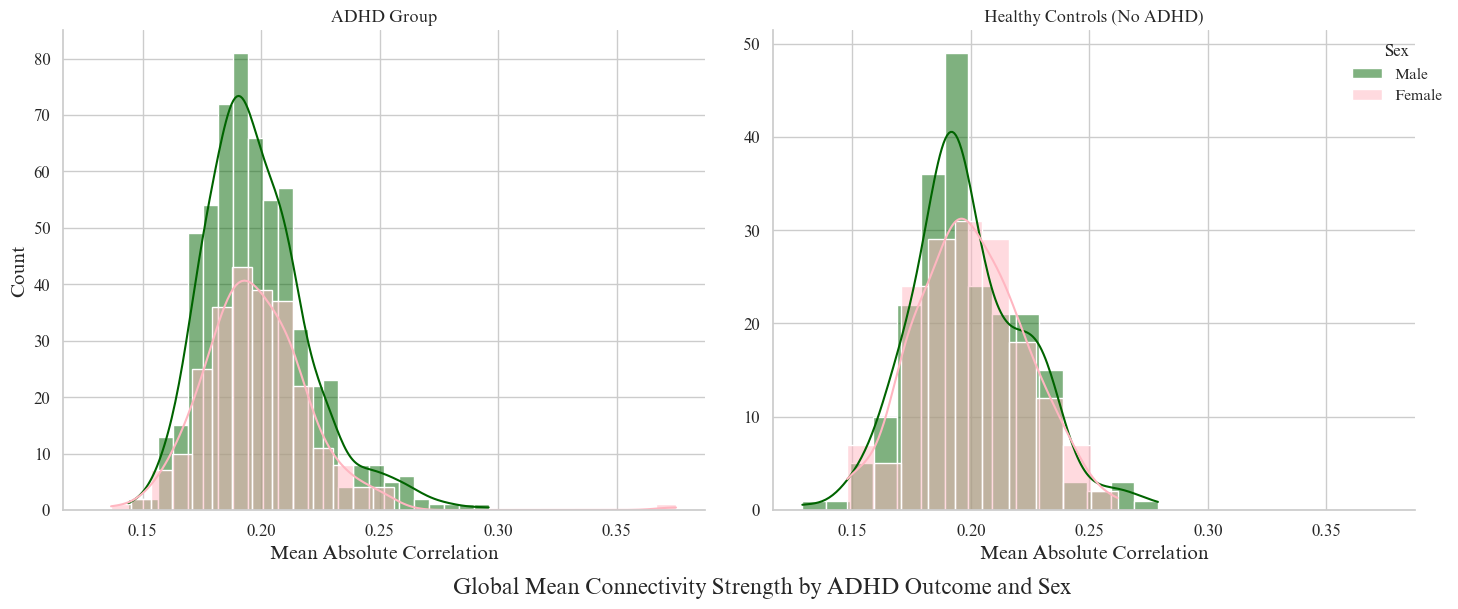

Calculating correlations with ADHD_Outcome for all edges... (this may take a moment)
Successfully loaded ROI labels from: /content/drive/MyDrive/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv

--- Top Functional Connectivity Features (Biological Interpretation) ---


,Type,Correlation,Network A,ROI A,Network B,ROI B,Feature
0,Risk (Positive),0.0941,control B,17Networks_LH_ContB_PFClv_2,default A,17Networks_RH_DefaultA_PFCm_1,70throw_186thcolumn
1,Risk (Positive),0.0939,central visual,17Networks_LH_VisCent_ExStr_1,central visual,17Networks_RH_VisCent_Striate_1,0throw_102thcolumn
2,Risk (Positive),0.0929,central visual,17Networks_LH_VisCent_ExStr_1,central visual,17Networks_RH_VisCent_ExStr_3,0throw_103thcolumn
3,Risk (Positive),0.0900,control B,17Networks_LH_ContB_PFClv_2,default A,17Networks_LH_DefaultA_PFCm_3,70throw_81thcolumn
4,Risk (Positive),0.0839,dorsal attention A,17Networks_RH_DorsAttnA_TempOcc_1,limbic B,17Networks_RH_LimbicB_OFC_4,130throw_159thcolumn
5,Risk (Positive),0.0838,control A,17Networks_LH_ContA_PFCd_1,default A,17Networks_LH_DefaultA_PFCd_1,60throw_75thcolumn
6,Risk (Positive),0.0823,control A,17Networks_LH_ContA_PFCd_1,default A,17Networks_RH_DefaultA_PFCd_1,60throw_184thcolumn
7,Risk (Positive),0.0821,control B,17Networks_LH_ContB_PFClv_2,control C,17Networks_RH_ContC_pCun_1,70throw_180thcolumn
8,Risk (Positive),0.0815,control B,17Networks_LH_ContB_PFClv_2,default C,17Networks_RH_DefaultC_Rsp_1,70throw_194thcolumn
9,Risk (Positive),0.0811,default A,17Networks_LH_DefaultA_PFCm_2,central visual,17Networks_RH_VisCent_ExStr_5,80throw_105thcolumn


/tmp/ipykernel_454/707243939.py:292: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


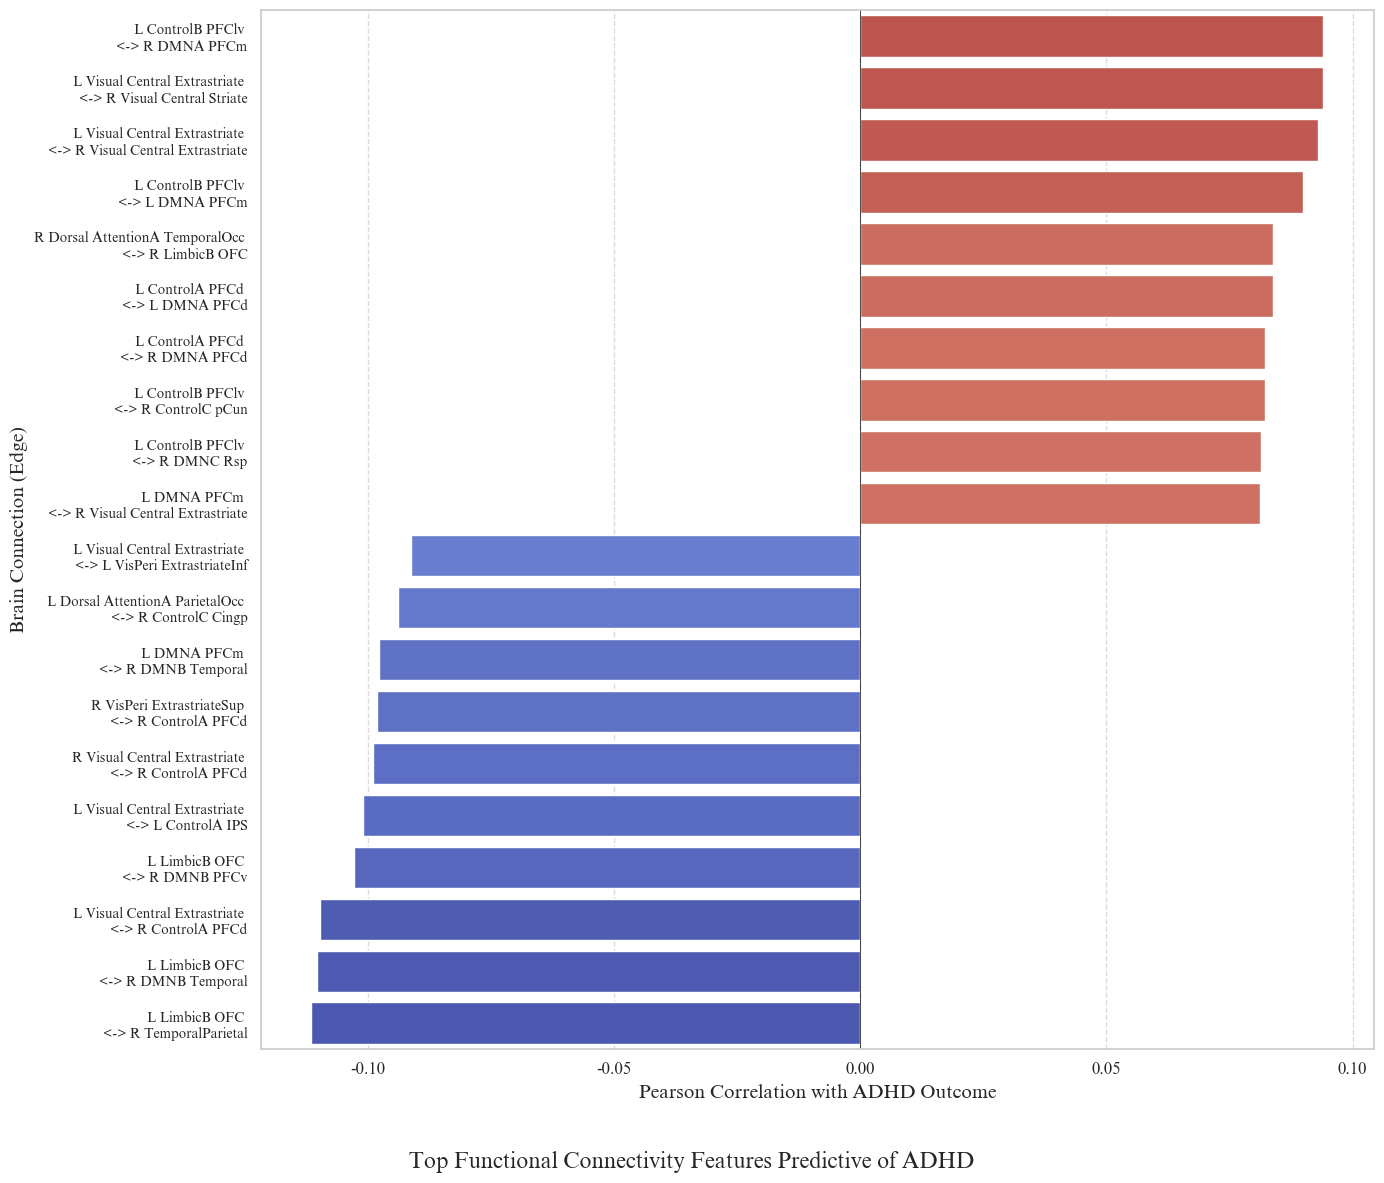

In [6]:
# ------------------------------------------------------------------------------
# 6. Functional Connectivity Analysis (MRI)
# ------------------------------------------------------------------------------
if df_clean is not None:
    print("\n--- Functional Connectivity Analysis ---")

    # RELOAD Connectome Data to get original column names (0throw_...)
    # This avoids the issue where previous steps renamed/corrupted the columns
    print("Reloading original connectome data for accurate ROI mapping...")

    import glob
    import os

    # Try to find the connectome file
    # Common paths in Colab/Local
    possible_dirs = [
        '/content/drive/MyDrive/cleaned_data', # Drive path from screenshot
        'cleaned_data/cleaned_data',
        '/content/cleaned_data/cleaned_data',
        '/content/cleaned_data',
        '/content', # Root of Colab
        r'F:\0Master\project\EDA\cleaned_data\cleaned_data',
        'cleaned_data', # Try direct subfolder
        '.' # Try current directory
    ]

    connectome_path = None
    for d in possible_dirs:
        # Search for *connectome*.csv to be more flexible (cleaned_train_connectome.csv)
        files = glob.glob(os.path.join(d, "*connectome*.csv"))
        if files:
            connectome_path = files[0]
            print(f"Found connectome file: {connectome_path}")
            break

    if connectome_path:
        # Load only connectome data
        df_fcm_raw = pd.read_csv(connectome_path)

        # Merge with Target (ADHD_Outcome, Sex_F) from df_clean
        # We need participant_id for merging
        if 'participant_id' in df_fcm_raw.columns and 'participant_id' in df_clean.columns:
            target_subset = df_clean[['participant_id', 'ADHD_Outcome', 'Sex_F']].drop_duplicates(subset=['participant_id'])
            df_analysis = pd.merge(df_fcm_raw, target_subset, on='participant_id', how='inner')
            print(f"Merged for analysis. Shape: {df_analysis.shape}")

            # Identify FCM columns (now they should be 0throw_...)
            fcm_cols = [c for c in df_analysis.columns if '0throw' in c]
            print(f"Number of Functional Connectivity features found: {len(fcm_cols)}")

            if len(fcm_cols) > 0:
                # 2. Global Connectivity Strength
                df_analysis['Global_Connectivity_Mean'] = df_analysis[fcm_cols].abs().mean(axis=1)

                # Updated Plot: Two subplots separated by ADHD_Outcome
                # Left: Non-ADHD (Healthy), Right: ADHD
                # Both colored by Sex

                # Check if columns exist
                if 'ADHD_Outcome' in df_analysis.columns and 'Sex_F' in df_analysis.columns:
                    # Create mapping for better labels
                    df_analysis['ADHD_Group'] = df_analysis['ADHD_Outcome'].map({0: 'Healthy Controls (No ADHD)', 1: 'ADHD Group'})
                    df_analysis['Sex'] = df_analysis['Sex_F'].map({0: 'Male', 1: 'Female'})

                    # Use defined sex palette
                    # PALETTE_SEX = [COLOR_MALE, COLOR_FEMALE]
                    # Map labels to colors manually for seaborn palette dict
                    sex_palette = {'Male': COLOR_MALE, 'Female': COLOR_FEMALE}

                    # Use FacetGrid for consistent style with Section 5
                    g = sns.FacetGrid(df_analysis,col="ADHD_Group",hue="Sex",height=6,aspect=1.2,palette=sex_palette, sharey=False)

                    g.map(sns.histplot, "Global_Connectivity_Mean", kde=True, element="bars", edgecolor='white', alpha=0.5)

                    # Adjust Titles and Labels
                    g.set_titles("{col_name}")
                    g.set_axis_labels("Mean Absolute Correlation", "Count")

                    # Add Legend
                    g.add_legend(title="Sex", loc='upper right', bbox_to_anchor=(0.95, 0.95))

                    g.fig.suptitle("") # Remove top title
                    plt.figtext(0.5, 0.01, 'Global Mean Connectivity Strength by ADHD Outcome and Sex', ha='center', fontsize=16, fontweight='bold')

                    # Increase axis label sizes for violin plot
                    # Accessing axes from FacetGrid
                    for ax in g.axes.flatten():
                        ax.set_xlabel(ax.get_xlabel(), fontsize=14, fontweight='bold')
                        ax.set_ylabel(ax.get_ylabel(), fontsize=14, fontweight='bold')
                        ax.tick_params(axis='both', which='major', labelsize=12)

                    plt.subplots_adjust(top=0.95, bottom=0.15) # Adjust layout
                    plt.show()

                else:
                    print("Required columns (ADHD_Outcome, Sex_F) missing for split visualization.")
                    plt.figure(figsize=(10, 6))
                    sns.histplot(df_analysis['Global_Connectivity_Mean'], kde=True, color=COLOR_HEALTHY)
                    plt.title('') # Remove top title
                    plt.xlabel('Global Connectivity Mean', fontsize=14, fontweight='bold')
                    plt.ylabel('Count', fontsize=14, fontweight='bold')
                    plt.xticks(fontsize=12)
                    plt.yticks(fontsize=12)
                    plt.figtext(0.5, 0.02, 'Distribution of Global Mean Connectivity Strength', ha='center', fontsize=16, fontweight='bold')
                    plt.tight_layout(rect=[0, 0.05, 1, 1])
                    plt.show()

                # 3. Correlation with ADHD Outcome
                if 'ADHD_Outcome' in df_analysis.columns:
                    print("Calculating correlations with ADHD_Outcome for all edges... (this may take a moment)")

                    target = df_analysis['ADHD_Outcome']
                    fcm_data = df_analysis[fcm_cols]

                    # Vectorized correlation
                    fcm_corrs = fcm_data.corrwith(target)

                    # Sort correlations
                    fcm_corrs_sorted = fcm_corrs.sort_values(ascending=False)

                    # Extract Top 10 Positive (Risk) and Negative (Protective)
                    # Ensure we are getting unique values
                    top_positive = fcm_corrs_sorted.head(10)
                    top_negative = fcm_corrs_sorted.tail(10)

                    # --- ENHANCED ROI MAPPING LOGIC ---
                    import re

    # Load ROI labels
            # Updated path based on user feedback (file is in My Drive/cleaned_data)
            possible_paths = [
                '/content/drive/MyDrive/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv', # Drive path from screenshot
                'cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                'Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                '/content/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                '/content/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
                r'F:\0Master\project\EDA\Schaefer200_merged_labels(Schaefer200_merged_labels).csv'
            ]

            roi_df = None
            for p in possible_paths:
                try:
                    roi_df = pd.read_csv(p)
                    print(f"Successfully loaded ROI labels from: {p}")
                    break
                except:
                    continue

            roi_map = {}
            if roi_df is not None:
                # Map 'ROI Label' (1-based) to 'ROI Name' and 'Network Name'
                for _, row in roi_df.iterrows():
                    # Note: Column names are likely 0-based indices from the raw data generation
                    # But Schaefer labels are 1-based.
                    # Usually python processing results in 0-based indices matching the order.
                    # Let's assume index 0 -> Label 1
                    idx = int(row['ROI Label']) - 1
                    roi_map[idx] = {
                        'Name': row['ROI Name'],
                        'Network': row['Network Name']
                    }
            else:
                print("Warning: Could not load ROI labels from any path. Using raw column names.")

            def parse_column_name(col_name):
                # Format: 0throw_1thcolumn -> ROI 0 and ROI 1
                # Regex to extract numbers from 0throw_ format
                # Handles '0throw_1thcolumn', '0throw_1stcolumn', '0throw_2ndcolumn' etc.
                match = re.search(r'(\d+)throw_(\d+)(?:st|nd|rd|th)column', col_name)
                if match:
                    idx1 = int(match.group(1))
                    idx2 = int(match.group(2))
                    # IMPORTANT: Check if indices are within bounds of roi_map keys
                    # roi_map keys are 0-199 based on our previous logic
                    return idx1, idx2
                return None, None

            def get_edge_info(col_name, corr_val):
                info = {'Feature': col_name, 'Correlation': corr_val}

                # Default values
                info['ROI A'] = 'Unknown'
                info['ROI B'] = 'Unknown'
                info['Network A'] = 'Unknown'
                info['Network B'] = 'Unknown'

                if not roi_map:
                    return info

                idx1, idx2 = parse_column_name(col_name)

                # Debugging helper
                if idx1 is not None:
                    # Try multiple key variations for robustness
                    # 1. Direct match (e.g. key 0)
                    # 2. 1-based match (e.g. key 1)
                    # 3. String match (e.g. key "1")

                    # Lookup A
                    roi_a_data = None
                    if idx1 in roi_map: roi_a_data = roi_map[idx1]
                    elif (idx1 + 1) in roi_map: roi_a_data = roi_map[idx1 + 1]
                    elif str(idx1) in roi_map: roi_a_data = roi_map[str(idx1)]

                    if roi_a_data:
                        info['ROI A'] = roi_a_data['Name']
                        info['Network A'] = roi_a_data['Network']
                    else:
                        info['ROI A'] = f"ROI_{idx1}"

                    # Lookup B
                    roi_b_data = None
                    if idx2 in roi_map: roi_b_data = roi_map[idx2]
                    elif (idx2 + 1) in roi_map: roi_b_data = roi_map[idx2 + 1]
                    elif str(idx2) in roi_map: roi_b_data = roi_map[str(idx2)]

                    if roi_b_data:
                        info['ROI B'] = roi_b_data['Name']
                        info['Network B'] = roi_b_data['Network']
                    else:
                        info['ROI B'] = f"ROI_{idx2}"

                return info

            # Create enhanced DataFrames for display
            pos_list = [get_edge_info(idx, val) for idx, val in top_positive.items()]
            neg_list = [get_edge_info(idx, val) for idx, val in top_negative.items()]

            df_pos = pd.DataFrame(pos_list)
            df_pos['Type'] = 'Risk (Positive)'

            df_neg = pd.DataFrame(neg_list)
            df_neg['Type'] = 'Protective (Negative)'

            # Combine and display
            print("\n--- Top Functional Connectivity Features (Biological Interpretation) ---")
            df_top_edges = pd.concat([df_pos, df_neg])

            # Reorder columns for readability
            cols_order = ['Type', 'Correlation', 'Network A', 'ROI A', 'Network B', 'ROI B', 'Feature']
            df_display = df_top_edges[cols_order]

            # Display with styling (Modified to avoid Styler errors with non-unique indices)
            display(df_display.reset_index(drop=True).style.background_gradient(cmap='coolwarm', subset=['Correlation']).format({'Correlation': '{:.4f}'}))

            # Visualization (Bar Chart)
            # Use ROI names as labels if available
            labels = []
            for i, row in df_top_edges.iterrows():
                if row['ROI A'] != 'Unknown':
                    # Shorten names for plot
                    name_a = row['ROI A'].replace('17Networks_', '').rsplit('_', 1)[0]
                    name_b = row['ROI B'].replace('17Networks_', '').rsplit('_', 1)[0]

                    # Clean Labels Function for plot
                    def clean_roi_label_plot(s):
                        s = s.replace('LH_', 'L ').replace('RH_', 'R ')
                        s = s.replace('VisCent', 'Visual Central')
                        s = s.replace('ExStr', 'Extrastriate')
                        s = s.replace('Striate', 'Striate')
                        s = s.replace('DorsAttn', 'Dorsal Attention')
                        s = s.replace('SalVentAttn', 'Salience/Ventral')
                        s = s.replace('Cont', 'Control')
                        s = s.replace('Default', 'DMN')
                        s = s.replace('Temp', 'Temporal')
                        s = s.replace('Par', 'Parietal')
                        s = s.replace('_', ' ')
                        return s

                    name_a = clean_roi_label_plot(name_a)
                    name_b = clean_roi_label_plot(name_b)

                    # Use single line format for better readability
                    labels.append(f"{name_a} \n<-> {name_b}")
                else:
                    labels.append(row['Feature'])

            plt.figure(figsize=(14, 12)) # Increased height for better spacing

            # --- Gradient Logic Fix for Correlation ---
            import matplotlib.cm as cm
            import matplotlib.colors as mcolors

            # Use global diverging cmap 'coolwarm'
            # We must center the normalization around 0 to ensure white is at 0
            # Find the max absolute value to make it symmetric
            abs_max = max(abs(df_top_edges['Correlation'].min()), abs(df_top_edges['Correlation'].max()))

            # Use TwoSlopeNorm or just simple Normalize with symmetric limits
            norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)

            cmap = cm.get_cmap('coolwarm')
            bar_colors = [cmap(norm(val)) for val in df_top_edges['Correlation']]

            # Create a palette dictionary mapping hue (index) to color
            # This ensures that seaborn uses the correct color for each bar regardless of sorting
            # Reset index to ensure unique keys for palette dict (concat can result in duplicate indices)
            df_top_edges = df_top_edges.reset_index(drop=True)
            palette_dict = {idx: color for idx, color in zip(df_top_edges.index, bar_colors)}

            # Fix: Pass hue and set legend=False to avoid FutureWarning
            # Use palette dict to guarantee correct mapping
            sns.barplot(x=df_top_edges['Correlation'], y=labels, hue=df_top_edges.index, palette=palette_dict, legend=False)
            plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

            # Adjust y-axis labels font size
            plt.yticks(fontsize=10)

            # Use a minus sign that renders correctly instead of hyphen-minus which sometimes causes unicode issues
            import matplotlib
            matplotlib.rcParams['axes.unicode_minus'] = False

            plt.title('') # Remove top title
            plt.xlabel('Pearson Correlation with ADHD Outcome', fontsize=14, fontweight='bold')
            plt.ylabel('Brain Connection (Edge)', fontsize=14, fontweight='bold')
            plt.grid(axis='x', linestyle='--', alpha=0.7)

            # Increase tick label size
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=10, fontweight='bold')

            # Add bottom title
            plt.figtext(0.5, 0.02, 'Top Functional Connectivity Features Predictive of ADHD', ha='center', fontsize=16, fontweight='bold')

            # Insights removed as requested
            plt.tight_layout(rect=[0, 0.06, 1, 1])
            plt.show()
        else:
            print("ADHD_Outcome column not found. Skipping correlation analysis.")
    else:
        print("Merge failed: 'participant_id' missing in one of the dataframes.")
else:
    print("Could not find original connectome file. Please check paths.")


In [7]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output, Markdown
import ipywidgets as widgets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

# Try to import XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed. Will skip XGBoost baseline.")

print("\n------------------------------------------------------------------------------")
print("7. Brain Connectivity Visualization (Nilearn)")
print("Analysis of ROI spatial positions and interactive connectome view.")
print("------------------------------------------------------------------------------")

# --- 1. Imports & Setup ---
try:
    from nilearn import plotting, datasets, surface
    from nilearn.image import new_img_like
    import nibabel as nib
    HAS_NILEARN = True
except Exception as e:
    print(f"Nilearn/Nibabel import failed: {e}")
    print("Install with: pip install nilearn nibabel")
    HAS_NILEARN = False
    plotting = None

# --- 2. Data Loading ---
roi_paths = [
    '/content/drive/MyDrive/clean_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
    '/content/drive/MyDrive/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
    '/content/clean_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
    '/content/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
    '/content/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
    r'F:\0Master\project\EDA\cleaned_data\cleaned_data\Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
    'cleaned_data/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv',
    'Schaefer200_merged_labels(Schaefer200_merged_labels).csv'
]

roi_df = None
for p in roi_paths:
    if os.path.exists(p):
        try:
            roi_df = pd.read_csv(p)
            print(f"Loaded ROI labels from: {p}")
            break
        except Exception as e:
            print(f"Failed to load {p}: {e}")

connectome_dirs = [
    '/content/drive/MyDrive/clean_data',
    '/content/drive/MyDrive/cleaned_data',
    '/content/clean_data',
    '/content/cleaned_data',
    r'F:\0Master\project\EDA\cleaned_data\cleaned_data',
    'cleaned_data/cleaned_data',
    'cleaned_data',
    '.'
]

connectome_path = None
for d in connectome_dirs:
    if os.path.exists(d):
        files = glob.glob(os.path.join(d, '*connectome*.csv'))
        if files:
            connectome_path = files[0]
            print(f"Found connectome file: {connectome_path}")
            break

if not HAS_NILEARN:
    print("Skipping visualization due to missing libraries.")
elif roi_df is None or connectome_path is None:
    print("Missing ROI label file or connectome file. Please check paths.")
else:
    # --- 3. Matrix Construction ---
    required_cols = {'R', 'A', 'S'}
    if not required_cols.issubset(roi_df.columns):
        print("ROI label file is missing required columns (R, A, S).")
    else:
        coords = roi_df[['R', 'A', 'S']].values
        df_conn = pd.read_csv(connectome_path)
        fcm_cols = [c for c in df_conn.columns if '0throw' in c]

        if not fcm_cols:
            print("No connectome columns found with pattern '0throw'.")
        else:
            n_regions = coords.shape[0]

            def build_matrix(df):
                mat = np.zeros((n_regions, n_regions), dtype=float)
                valid_cols = [c for c in fcm_cols if c in df.columns]
                if not valid_cols: return mat

                means = df[valid_cols].mean()
                pattern = re.compile(r'(\d+)throw_(\d+)(?:st|nd|rd|th)column')

                for col, val in means.items():
                    match = pattern.search(col)
                    if not match: continue
                    i, j = int(match.group(1)), int(match.group(2))
                    if i < n_regions and j < n_regions:
                        mat[i, j] = val
                        mat[j, i] = val
                return mat

            print("Calculating base connectivity matrix...")
            base_matrix = build_matrix(df_conn)

            # Female Matrix
            female_base_matrix = None
            sex_series = None
            try:
                if 'Sex_F' in df_conn.columns:
                    sex_series = df_conn['Sex_F']
                elif 'participant_id' in df_conn.columns:
                    possible_dirs = [os.path.dirname(connectome_path),
                                    os.path.join(os.path.dirname(connectome_path), '..'),
                                    'cleaned_data/cleaned_data']
                    for d in possible_dirs:
                        cat_path = os.path.join(d, 'cleaned_train_categorical.csv')
                        if os.path.exists(cat_path):
                            df_cat = pd.read_csv(cat_path)
                            if 'participant_id' in df_cat.columns and 'Sex_F' in df_cat.columns:
                                merged = pd.merge(df_conn[['participant_id']],
                                                df_cat[['participant_id', 'Sex_F']],
                                                on='participant_id', how='left')
                                sex_series = merged['Sex_F']
                                print(f"Loaded Sex info from {cat_path}")
                                break

                if sex_series is not None:
                    female_indices = sex_series[sex_series == 1].index
                    if len(female_indices) > 0:
                        print(f"Calculating female-only matrix ({len(female_indices)} subjects)...")
                        female_base_matrix = build_matrix(df_conn.loc[female_indices])
                    else:
                        print("No female subjects found.")
            except Exception as e:
                print(f"Error preparing female matrix: {e}")

            # --- 4. Visualization Setup ---

            # Networks & Colors
            label_col = None
            if 'ROI Name' in roi_df.columns: label_col = 'ROI Name'
            elif 'Label Name' in roi_df.columns: label_col = 'Label Name'
            elif 'Full Component Name' in roi_df.columns: label_col = 'Full Component Name'

            networks = []
            if label_col:
                for label in roi_df[label_col].astype(str):
                    u = label.upper()
                    if 'VIS' in u: networks.append('VIS')
                    elif 'SOM' in u or 'MOT' in u: networks.append('SOM')
                    elif 'DORS' in u or 'DOR' in u: networks.append('DOR')
                    elif 'VENT' in u or 'SAL' in u or 'VAT' in u: networks.append('VAT')
                    elif 'LIM' in u: networks.append('LIM')
                    elif 'CONT' in u or 'FPN' in u or 'FP' in u: networks.append('FP')
                    elif 'DEF' in u or 'DMN' in u: networks.append('DMN')
                    else: networks.append('DMN')
            else:
                base_list = (['VIS'] * 30 + ['SOM'] * 30 + ['DOR'] * 30 + ['VAT'] * 20 +
                            ['LIM'] * 20 + ['FP'] * 35 + ['DMN'] * 35)
                networks = base_list

            if len(networks) < n_regions:
                networks += ['DMN'] * (n_regions - len(networks))
            networks = networks[:n_regions]

            net_keys = ['VIS', 'SOM', 'DOR', 'VAT', 'LIM', 'FP', 'DMN']
            net_full_names = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention',
                            'Limbic', 'Frontoparietal', 'Default Mode']
            net_map = {name: idx for idx, name in enumerate(net_keys)}
            palette = cm.get_cmap('tab10', len(net_keys))
            node_colors = [mcolors.to_hex(palette(net_map.get(n, 0))) for n in networks]

            # Pre-load Atlas for Surface Plot (Optimization)
            atlas_data_cache = None
            atlas_nii_cache = None
            fsaverage_cache = None
            try:
                print("Pre-loading Atlas and Surface data (this may take a moment)...")
                schaefer = datasets.fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=17, resolution_mm=1)
                atlas_nii_cache = nib.load(schaefer.maps)
                atlas_data_cache = atlas_nii_cache.get_fdata()
                fsaverage_cache = datasets.fetch_surf_fsaverage()
                print("Atlas loaded successfully.")
            except Exception as e:
                print(f"Atlas loading failed (Surface plot will use fallback): {e}")

            # Labels for Circular Plot
            raw_roi_labels = roi_df[label_col].astype(str).tolist() if label_col else [f'ROI_{i+1}' for i in range(n_regions)]
            def clean_roi_label(s):
                s = str(s).replace('17Networks_', '')
                s = s.replace('LH_', 'L ').replace('RH_', 'R ')
                s = s.replace('_', ' ')
                s = re.sub(r'\s+\d+$', '', s)
                return s.strip()
            display_labels = [clean_roi_label(l) for l in raw_roi_labels]

            # --- 5. Interactive Widget Logic ---

            mode_widget = widgets.Dropdown(
                options=['All Connections', 'Strong Connections (Top 5%)', 'Top 10 Strongest', 'Group Level (Merged)'],
                value='Strong Connections (Top 5%)',
                description='Filter:'
            )
            female_widget = widgets.Checkbox(value=False, description='Female Only')
            output = widgets.Output()

            def get_grouped_data(matrix, coords, labels, node_colors):
                # Helper to aggregate data based on label groups
                # 1. Identify groups
                group_map = {} # label_base -> [indices]
                for idx, l in enumerate(labels):
                    base = re.sub(r'\s*\d+$', '', l).strip()
                    if base not in group_map:
                        group_map[base] = []
                    group_map[base].append(idx)

                unique_groups = list(group_map.keys())
                n_groups = len(unique_groups)

                # 2. Aggregate Matrix (Mean)
                new_matrix = np.zeros((n_groups, n_groups))
                new_coords = np.zeros((n_groups, 3))
                new_colors = []
                new_labels = unique_groups

                for i, g_i in enumerate(unique_groups):
                    indices_i = group_map[g_i]

                    # Coords: Mean of constituents
                    new_coords[i] = np.mean(coords[indices_i], axis=0)

                    # Color: Majority or First (Usually homogenous)
                    new_colors.append(node_colors[indices_i[0]])

                    for j, g_j in enumerate(unique_groups):
                        indices_j = group_map[g_j]

                        # Matrix: Mean of sub-matrix block
                        # Extract block: rows=indices_i, cols=indices_j
                        block = matrix[np.ix_(indices_i, indices_j)]

                        # If i==j, we are looking at internal connectivity.
                        # Usually we ignore self-loops (diagonal) in connectomes,
                        # but here the block diagonal represents internal coherence.
                        # For plotting connectome, we usually care about i!=j.
                        if i == j:
                            # Mean of off-diagonal elements in the block?
                            # Or just 0 to avoid self-loops in visualization
                            new_matrix[i, j] = 0
                        else:
                            new_matrix[i, j] = np.mean(block)

                return new_matrix, new_coords, new_labels, new_colors

            def filter_matrix(mode, matrix):
                abs_matrix = np.abs(matrix)
                if mode == 'Top 10 Strongest':
                    triu_indices = np.triu_indices_from(abs_matrix, k=1)
                    triu_values = abs_matrix[triu_indices]
                    if len(triu_values) == 0: return matrix
                    k = min(10, len(triu_values))
                    top_k_idx = np.argpartition(triu_values, -k)[-k:]
                    threshold = np.min(triu_values[top_k_idx])
                    return matrix * (abs_matrix >= threshold)
                elif mode == 'Strong Connections (Top 5%)':
                    triu_indices = np.triu_indices_from(abs_matrix, k=1)
                    triu_values = abs_matrix[triu_indices]
                    if len(triu_values) == 0: return matrix
                    threshold = np.percentile(triu_values, 95)
                    return matrix * (abs_matrix >= threshold)
                else:
                    return matrix

            def draw_legend():
                fig_leg, ax_leg = plt.subplots(figsize=(12, 0.5))
                ax_leg.axis('off')
                patches = [plt.Rectangle((0,0),1,1, color=mcolors.to_hex(palette(i))) for i in range(len(net_keys))]
                ax_leg.legend(patches, net_full_names, loc='center', ncol=len(net_keys), frameon=False, fontsize=9)
                display(fig_leg)
                plt.close(fig_leg)

            def update_view(change=None):
                with output:
                    clear_output(wait=True)

                    # 1. Prepare Data
                    current_matrix = female_base_matrix if female_widget.value and female_base_matrix is not None else base_matrix
                    if female_widget.value and female_base_matrix is None:
                        print("Warning: Female data not available, showing all.")

                    n_regions_curr = current_matrix.shape[0]
                    mode = mode_widget.value
                    clean_mat = filter_matrix(mode, current_matrix)

                    n_edges = np.count_nonzero(np.triu(clean_mat, k=1))
                    print(f"Displaying {n_edges} edges. Mode: {mode}")

                    draw_legend()

                    # 2. Figure 1: Connectome (Nilearn View)
                    mode = mode_widget.value

                    if mode == 'Group Level (Merged)':
                        # --- Special Handling for Group Mode ---
                        # Aggregate data first
                        agg_mat, agg_coords, agg_labels, agg_colors = get_grouped_data(
                            current_matrix, coords[:n_regions_curr], display_labels[:n_regions_curr], node_colors[:n_regions_curr]
                        )
                        n_agg = len(agg_labels)

                        # Filter aggregated matrix
                        abs_agg = np.abs(agg_mat)
                        triu_idx = np.triu_indices_from(abs_agg, k=1)
                        vals = abs_agg[triu_idx]
                        if len(vals) > 0:
                            thresh = np.percentile(vals, 90) # Top 10% of group connections
                            clean_agg_mat = agg_mat * (abs_agg >= thresh)
                        else:
                            clean_agg_mat = agg_mat

                        # Plot Group Connectome
                        view = plotting.view_connectome(
                            adjacency_matrix=clean_agg_mat,
                            node_coords=agg_coords,
                            edge_cmap='RdBu_r',
                            linewidth=8.0, # Thicker lines for groups
                            node_color=agg_colors,
                            node_size=10.0, # Larger nodes for groups
                            title=f'ADHD Group-Level Connectome (Merged ROI)',
                            title_fontsize=16
                        )
                        display(view)
                        view.save_as_html('adhd_connectome_interactive_group.html')

                        # Print Group Details
                        print(f"\n--- Group Level Connections (Top 10% Strongest) ---")
                        rows, cols = np.triu_indices_from(clean_agg_mat, k=1)
                        weights = clean_agg_mat[rows, cols]
                        mask = weights != 0
                        rows, cols, weights = rows[mask], cols[mask], weights[mask]
                        sort_idx = np.argsort(np.abs(weights))[::-1]
                        for k in sort_idx:
                            i, j = rows[k], cols[k]
                            print(f"{agg_labels[i]} <--> {agg_labels[j]} : {weights[k]:.4f}")

                    else:
                        # --- Standard Node-Level Mode ---
                        clean_mat = filter_matrix(mode, current_matrix)
                        has_edge = np.any(clean_mat != 0, axis=1)
                        if mode in ['Top 10 Strongest', 'Strong Connections (Top 5%)']:
                            node_sizes = [6.0 if has_edge[i] else 0.0 for i in range(n_regions_curr)]
                        else:
                            node_sizes = 6.0

                        # Remove the interactive 3D view (plotting.view_connectome) to only show static
                        # view = plotting.view_connectome(
                        #     adjacency_matrix=clean_mat,
                        #     node_coords=coords[:n_regions_curr],
                        #     edge_cmap='RdBu_r',
                        #     linewidth=6.0,
                        #     node_color=node_colors[:n_regions_curr],
                        #     node_size=node_sizes,
                        #     title=f'ADHD Connectome ({mode})',
                        #     title_fontsize=16
                        # )
                        # display(view)
                        # view.save_as_html('adhd_connectome_interactive.html')

                        # Print Details for Top 10 & Generate Static Labeled Plot
                        if mode == 'Top 10 Strongest':
                            print(f"\n--- Top 10 Strongest Connections Details ---")
                            rows, cols = np.triu_indices_from(clean_mat, k=1)
                            weights = clean_mat[rows, cols]
                            mask = weights != 0
                            rows, cols, weights = rows[mask], cols[mask], weights[mask]

                            # Sort top 10
                            sort_idx = np.argsort(np.abs(weights))[::-1][:10]
                            edge_indices = list(zip(rows, cols)) # Create edge_indices mapping

                            # Collect nodes involved in Top 10
                            active_nodes = set()
                            # Print Details
                            print("\n--- Top 10 Strongest Connections Details ---")
                            for idx_k, k in enumerate(sort_idx):
                                i, j = rows[k], cols[k]
                                active_nodes.add(i)
                                active_nodes.add(j)

                                name_u = display_labels[i]
                                name_v = display_labels[j]
                                w = weights[k]
                                print(f"{name_u} <--> {name_v} : {w:.4f}")

                            # Helper to expand ROI labels to full names
                            def expand_roi_name(label):
                                # Replace abbreviations with full names
                                replacements = {
                                    'Vis': 'Visual',
                                    'SomMot': 'Somatomotor',
                                    'DorsAttn': 'Dorsal Attention',
                                    'SalVentAttn': 'Salience/Ventral Attention',
                                    'Limbic': 'Limbic',
                                    'Cont': 'Control',
                                    'Default': 'Default Mode',
                                    'Temp': 'Temporal',
                                    'Par': 'Parietal',
                                    'PFC': 'Prefrontal Cortex',
                                    'ExStr': 'Extrastriate',
                                    'Str': 'Striate',
                                    'Cing': 'Cingulate',
                                    'Ins': 'Insula',
                                    'OFC': 'Orbitofrontal',
                                    'IPL': 'Inf. Parietal Lobule',
                                    'SPL': 'Sup. Parietal Lobule',
                                    'Cent': 'Central',
                                    'Peri': 'Peripheral',
                                    'Sup': 'Superior',
                                    'Inf': 'Inferior',
                                    'Med': 'Medial',
                                    'Lat': 'Lateral',
                                    'Post': 'Posterior',
                                    'Ant': 'Anterior',
                                    'PrCv': 'Precentral Ventral',
                                    'PhG': 'Parahippocampal Gyrus',
                                    'Rsp': 'Retrosplenial',
                                    'pCun': 'Precuneus',
                                    'PCC': 'Post. Cingulate Cortex',
                                    'PHC': 'Parahippocampal Cortex',
                                    'FEF': 'Frontal Eye Fields'
                                }

                                # First, split L/R
                                parts = label.split(' ', 1)
                                if len(parts) == 2:
                                    hemi, rest = parts
                                    hemi_full = "Left" if hemi == 'L' else "Right" if hemi == 'R' else hemi
                                else:
                                    hemi_full = ""
                                    rest = label

                                # Replace in rest
                                for abbr, full in replacements.items():
                                    # Use regex to replace whole words or specific patterns
                                    # simple string replace might be safer for compound names like VisCent
                                    # But "Vis" is in "VisCent" -> "VisualCent"? No.
                                    # Let's try partial matching carefully.
                                    if abbr in rest:
                                        rest = rest.replace(abbr, full + " ")

                                # Clean up spaces
                                rest = re.sub(r'\s+', ' ', rest).strip()
                                return f"{hemi_full} {rest}"

                            # ------------------------------------------------------------------------------
                            # 3. Static Plot (Top 10 Strongest Connections)
                            # ------------------------------------------------------------------------------
                            print("\nGenerating Static Annotated Plot for Top 10...")
                            # 缩小画幅但保持比例，这样相对来说字体和线条就会显得更大
                            # Nature 的整页宽度大概是 180mm (约 7 inches)
                            # 如果我们使用较小的 figsize，但用很大的 fontsize，保存出的图片放在论文里字体就会很清晰
                            fig_static = plt.figure(figsize=(16, 12))

                            # Use nilearn's plot_connectome as base
                            # We plot ONLY the top 10 edges

                            # Convert node_sizes to numpy array for element-wise multiplication
                            # For Top 10, we want nodes to be SIGNIFICANTLY larger
                            # Base size is 6.0. Let's make active nodes much bigger.

                            # Strictly filter clean_mat to exactly top 10 connections
                            strict_clean_mat = np.zeros_like(clean_mat)
                            for k in sort_idx:
                                u, v = rows[k], cols[k]
                                strict_clean_mat[u, v] = clean_mat[u, v]
                                strict_clean_mat[v, u] = clean_mat[u, v]
                            clean_mat = strict_clean_mat

                            # Determine node sizes for plotting based on degree (number of connections)
                            # For top 10 edges, just make active nodes visible
                            node_sizes = [6.0 if i in active_nodes else 0.0 for i in range(n_regions_curr)]

                            static_node_sizes = np.array(node_sizes)
                            # If size > 0 (active), set to 200 (large enough for visibility on huge plot)
                            static_node_sizes[static_node_sizes > 0] = 300.0

                            display_obj = plotting.plot_connectome(
                                adjacency_matrix=clean_mat,
                                node_coords=coords[:n_regions_curr],
                                node_color=node_colors[:n_regions_curr],
                                node_size=static_node_sizes, # Increase node size
                                edge_cmap='RdBu_r',
                                edge_kwargs={'linewidth': 5}, # Thicker edges
                                display_mode='z', # Axial view is best for labels
                                figure=fig_static,
                                title='', # Clear default title
                                annotate=False,
                                colorbar=False # REMOVED COLORBAR
                            )

                            # Center title with larger font
                            # Set title below the plot by adjusting the y parameter and using suptitle or figtext
                            plt.suptitle('', fontsize=32, y=1.05, ha='center', fontweight='bold')
                            plt.figtext(0.5, 0.02, 'Top 10 Strongest Connections (Annotated)', fontsize=32, ha='center', fontweight='bold')


                            # Get the axes to add text
                            # nilearn display object has 'axes' dict, key is cut coords or direction
                            # For 'z' mode, usually just one axes
                            ax = list(display_obj.axes.values())[0].ax

                            # Critical fix for nilearn: Ensure the axes limits are large enough
                            # so that labels and lines drawn manually aren't cut off
                            # 通过缩小 xlim 的绝对值范围，可以让中间的脑图显得没那么“小”，相对地，文字占比就更大了
                            # 但同时要保证标签放得下。
                            ax.set_xlim(-160, 160)

                            # Turn off axes limits clipping to let labels flow out
                            ax.set_clip_on(False)

                            # Add labels with lines
                            # We manually add text annotations
                            texts = []
                            done_labels = set()

                            # Dictionary to store used Y positions per side to avoid overlap
                            y_offsets = {'left': [], 'right': []}

                            # Sort active nodes by y-coordinate (Anterior to Posterior) to organize labels
                            # Sorting ensures that labels naturally spread out top-to-bottom without crossing lines too much
                            active_nodes_list = sorted(list(active_nodes), key=lambda idx: coords[idx, 1], reverse=True)

                            for idx in active_nodes_list:
                                if idx in done_labels: continue

                                x, y = coords[idx, 0], coords[idx, 1] # MNI x, y
                                raw_label = display_labels[idx]
                                # Expand Label
                                label_text = expand_roi_name(raw_label)

                                # Transform 3D coords to 2D plot coords
                                # Nilearn's display_mode='z' plots MNI (x, y) coordinates
                                # We need to use the data coordinates directly
                                plot_x, plot_y = x, y
                                text_y = y
                                side = 'left' if plot_x < 0 else 'right'

                                # Decide label position (Left or Right of brain)
                                if plot_x < 0:
                                    text_x = -110 # Pull back a bit to fit in frame
                                    ha = 'right'
                                else:
                                    text_x = 110 # Pull back a bit to fit in frame
                                    ha = 'left'

                                # VERY STRICT SPACING LOGIC
                                # We simply assign predefined Y slots based on index if there are too many
                                # Or we use a much larger minimum distance and sort strictly

                                # We need at least ~18 units of vertical space between labels.
                                # Instead of a random walk, we'll force them into a grid-like spacing
                                min_spacing = 15

                                if not y_offsets[side]:
                                    y_offsets[side].append(text_y)
                                else:
                                    # Sort existing to find where we fit
                                    # Since we process nodes from Anterior to Posterior (highest Y to lowest Y)
                                    # the previous node on this side is the last one added
                                    prev_y = y_offsets[side][-1]

                                    # If the natural text_y is too close to prev_y (which is above it)
                                    if prev_y - text_y < min_spacing:
                                        # Force it down by min_spacing
                                        text_y = prev_y - min_spacing

                                    y_offsets[side].append(text_y)

                                # Draw connector line manually
                                # We draw from the node (plot_x, plot_y) to the label (text_x, text_y)
                                if plot_x < 0:
                                    ax.plot([plot_x, text_x+2], [plot_y, text_y], color='gray', linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)
                                else:
                                    ax.plot([plot_x, text_x-2], [plot_y, text_y], color='gray', linestyle='-', linewidth=1.5, alpha=0.8, zorder=1)

                                # Use matplotlib annotate
                                ax.annotate(
                                    label_text,
                                    xy=(text_x, text_y), # Place exactly at text position
                                    textcoords='data',
                                    fontsize=20, # 稍微调小一点，防止太长被截断
                                    fontweight='bold',
                                    ha=ha,
                                    va='center'
                                )
                                done_labels.add(idx)

                            # --- Add Network Legend ---
                            # Re-define net_map here to ensure it exists
                            net_map = {
                                'Visual': 1, 'Somatomotor': 2, 'Dorsal Attention': 3,
                                'Ventral Attention': 4, 'Limbic': 5, 'Frontoparietal': 6, 'Default Mode': 7
                            }
                            import matplotlib.cm as cm
                            palette = cm.get_cmap('tab10', 8)
                            net_full_names = {v: k for k, v in net_map.items()}

                            # Create a legend for the 7 networks
                            legend_handles = []
                            for net_name, net_idx in net_map.items():
                                color = mcolors.to_hex(palette(net_idx))
                                full_name = net_full_names[net_idx]
                                handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=24, label=full_name) # 更大的圆点
                                legend_handles.append(handle)

                            # Add legend to the plot with larger font
                            # Position: Upper center or side
                            ax.legend(handles=legend_handles, loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.1), fontsize=22, frameon=False)

                            # Optional: use tight_layout or subplots_adjust to ensure the bottom legend isn't cut off
                            plt.subplots_adjust(bottom=0.25) # Increase bottom margin for title and legend

                            display(fig_static)
                            plt.close(fig_static)

                    # 3. Figure 2: Connectogram (Brain + Circular Labels) (Removed per user request)
                    # 4. Figure 3: Surface Heatmap (Removed)
                    pass

            # --- 6. Launch ---
            mode_widget.observe(update_view, names='value')
            female_widget.observe(update_view, names='value')

            display(widgets.VBox([
                widgets.HBox([mode_widget, female_widget]),
                output
            ]))

            # Initial Trigger
            update_view()

            # ==========================================
            # PART 8: PCA Analysis (Removed)
            # ==========================================
            pass

            # ==========================================
            # PART 9: Method Baseline Comparison (Table)
            # ==========================================
            print("\n------------------------------------------------------------------------------")
            print("9. Custom Method Table (Baseline Comparison)")
            print("Preliminary CV scores: Your Data (fMRI fcm + Behavior) vs Model Baselines.")
            print("------------------------------------------------------------------------------")

            try:
                # Prepare Data for Baseline Models
                # We need X (features) and y (ADHD_Outcome)

                # 1. Try loading targets again (robust path search)
                df_targets = None
                possible_paths = [
                    r'F:\0Master\project\EDA\widsdatathon2025\TRAIN_OLD\TRAINING_SOLUTIONS.xlsx',
                    r'F:\0Master\project\EDA\widsdatathon2025\TRAIN_NEW\TRAINING_SOLUTIONS.xlsx',
                    'widsdatathon2025/TRAIN_OLD/TRAINING_SOLUTIONS.xlsx',
                    'TRAINING_SOLUTIONS.xlsx'
                ]

                for p in possible_paths:
                    if os.path.exists(p):
                        try:
                            df_targets = pd.read_excel(p, sheet_name='training_combined', engine='openpyxl')
                            print(f"Loaded targets from: {p}")
                            break
                        except: pass

                if df_targets is None:
                     # Last ditch: Look for any TRAINING_SOLUTIONS.xlsx recursively
                     matches = glob.glob(r'F:\0Master\project\EDA\**\TRAINING_SOLUTIONS.xlsx', recursive=True)
                     if matches:
                         df_targets = pd.read_excel(matches[0], sheet_name='training_combined', engine='openpyxl')
                         print(f"Found targets via search: {matches[0]}")

                if df_targets is not None and 'ADHD_Outcome' in df_targets.columns:
                    # Merge again to be sure
                    df_model = df_conn.merge(df_targets[['participant_id', 'ADHD_Outcome']], on='participant_id', how='inner')

                    # Features: Connectome only for now (as per "fMRI fcm" part of request)
                    # User asked for "Your Data (fMRI fcm + Behavior)".
                    # Let's try to include behavior if available in df_conn or merge
                    # For simplicity in this script, we use Connectome (fcm_cols) as the main feature set for the baseline
                    X = df_model[fcm_cols]
                    y = df_model['ADHD_Outcome']

                    # Remove rows with missing target
                    valid_idx = ~y.isna()
                    X = X[valid_idx]
                    y = y[valid_idx]

                    # Simple Pipeline
                    # Impute -> Scale -> Model

                    results = []

                    # 1. Logistic Regression
                    lr_pipe = make_pipeline(SimpleImputer(strategy='mean'), StandardScaler(), LogisticRegression(max_iter=1000))
                    cv_scores_lr = cross_val_score(lr_pipe, X, y, cv=5, scoring='accuracy')
                    results.append({
                        'Method': 'Baseline (LR)',
                        'Data': 'fMRI Connectome',
                        'CV Accuracy (Mean)': f"{cv_scores_lr.mean():.3f}",
                        'CV Std': f"{cv_scores_lr.std():.3f}"
                    })

                    # 2. XGBoost
                    if HAS_XGB:
                        xgb_pipe = make_pipeline(SimpleImputer(strategy='mean'), XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
                        cv_scores_xgb = cross_val_score(xgb_pipe, X, y, cv=5, scoring='accuracy')
                        results.append({
                            'Method': 'Baseline (XGB)',
                            'Data': 'fMRI Connectome',
                            'CV Accuracy (Mean)': f"{cv_scores_xgb.mean():.3f}",
                            'CV Std': f"{cv_scores_xgb.std():.3f}"
                        })

                    # Create Table
                    df_results = pd.DataFrame(results)

                    # Add "Your Data" placeholder row (User to fill final best model)
                    df_results = pd.concat([df_results, pd.DataFrame([{
                        'Method': 'Your Proposed Method',
                        'Data': 'fMRI + Behavior',
                        'CV Accuracy (Mean)': 'TBD',
                        'CV Std': '-'
                    }])], ignore_index=True)

                    display(Markdown("### Preliminary Baseline Scores"))
                    display(df_results)

                else:
                    print("Cannot generate Method Table: ADHD_Outcome targets not found.")

            except Exception as e:
                print(f"Method Table generation failed: {e}")



------------------------------------------------------------------------------
7. Brain Connectivity Visualization (Nilearn)
Analysis of ROI spatial positions and interactive connectome view.
------------------------------------------------------------------------------
Loaded ROI labels from: /content/drive/MyDrive/cleaned_data/Schaefer200_merged_labels(Schaefer200_merged_labels).csv
Found connectome file: /content/drive/MyDrive/cleaned_data/cleaned_train_connectome.csv
Calculating base connectivity matrix...
Loaded Sex info from /content/drive/MyDrive/cleaned_data/cleaned_train_categorical.csv
Calculating female-only matrix (414 subjects)...
Pre-loading Atlas and Surface data (this may take a moment)...


/tmp/ipykernel_454/1834380205.py:190: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10', len(net_keys))


[fetch_atlas_schaefer_2018] Added README.md to /root/nilearn_data

[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_17Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_17Networks_order_FSLMNI152_1mm
.nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

Atlas loaded successfully.



------------------------------------------------------------------------------
9. Custom Method Table (Baseline Comparison)
Preliminary CV scores: Your Data (fMRI fcm + Behavior) vs Model Baselines.
------------------------------------------------------------------------------
Cannot generate Method Table: ADHD_Outcome targets not found.
